# Results Figures

All visualizations for the VOTC reorganization study.
Companion to `results_master.ipynb`.

**Figures:**
1. Cross-sectional selectivity violins (from 02_sum-select)
2. Longitudinal selectivity change dots (from 02_sum-select)
3. Liu distinctiveness cross-sectional violins
4. Geometry preservation by category (from 04_geometry-2)
5. Geometry slope: unilateral vs bilateral (from 04_geometry-2)
6. Bilateral vs unilateral scatter
7. **Standardized measure overview** — bar/dot plot for every measure

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: Setup
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats as sp_stats
from scipy.stats import ttest_rel, ttest_ind

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE     = Path(processed_dir)
SEL_DIR  = BASE / 'group_results' / 'selectivity'
LIU_DIR  = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR  = BASE / 'group_results' / 'geometry'
PEAK_DIR = BASE / 'group_results' / 'peak_coords'
FIG_DIR  = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET   = 'differential'
EXCLUDE    = ['sub-017']
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']
PREFERRED_HEMI = {'face': 'right', 'word': 'left', 'house': 'right', 'object': 'left'}
REORG = {'left': 'word', 'right': 'face'}

N_ITER = 10_000
RNG    = np.random.default_rng(42)

CTRL_L = '#a0a0a0'; CTRL_R = '#505050'
OTC_L  = '#7398af'; OTC_R  = '#ee7183'
NONOT  = '#FF9800'

CAT_COLORS  = {'face': '#cc0066', 'word': '#ff8800', 'house': '#009900', 'object': '#0077cc'}
CAT_MARKERS = {'face': 'o', 'word': 's', 'house': '^', 'object': 'D'}

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

def short_name(code):
    return code.replace('sub-', '').replace('OTC', '').replace('nonOTC', 'n').replace('control', 'c')

def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std
    sy = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

print(f'Setup complete. Figures → {FIG_DIR}')

Setup complete. Figures → /user_data/csimmon2/sym_pt/group_results/figures


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: Load All Data
# ═══════════════════════════════════════════════════════════════════════════════

# ── Selectivity (cross-sectional = first session) ─────────────────────────
sel_file = SEL_DIR / 'selectivity_summary.csv'
df_sel = pd.read_csv(sel_file)
df_sel = df_sel[~df_sel['sub'].isin(EXCLUDE)]
df_sel['ses_int'] = df_sel['ses'].astype(int)
first_ses = df_sel.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
df_sel_cs = df_sel.merge(first_ses, on='sub')
df_sel_cs = df_sel_cs[df_sel_cs['ses_int'] == df_sel_cs['fs']].copy()

ctrl = df_sel_cs[df_sel_cs['group'] == 'control'].copy()
otc  = df_sel_cs[df_sel_cs['group'] == 'OTC'].copy()
nonotc = df_sel_cs[df_sel_cs['group'] == 'nonOTC'].copy()
otc['surgery_side'] = otc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')
nonotc['surgery_side'] = nonotc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

# Lateralization
ctrl_wide = {}
lat_results = {}
for cat in CATEGORIES:
    piv = ctrl[ctrl['category'] == cat][['sub', 'hemi', 'sum_selec_norm']].pivot(
        index='sub', columns='hemi', values='sum_selec_norm').dropna()
    ctrl_wide[cat] = piv
    if len(piv) >= 3:
        t, p = ttest_rel(piv['left'].values, piv['right'].values)
        lat_results[cat] = {'t': t, 'p': p, 'sig': p < 0.05 / len(CATEGORIES)}

# Bootstrap resamples
resample_file = SEL_DIR / 'resamples' / 'sum_selec_norm_resamples.csv'
df_boot = pd.read_csv(resample_file) if resample_file.exists() else None

# ── Liu Distinctiveness ───────────────────────────────────────────────────
liu_file = LIU_DIR / f'liu_distinctiveness_{COPE_SET}.csv'
df_liu = pd.read_csv(liu_file)
df_liu = df_liu[~df_liu['subject_id'].isin(EXCLUDE)]
df_liu = df_liu[df_liu['category'].isin(CATEGORIES)]
df_liu['ses_num'] = pd.to_numeric(df_liu['session'], errors='coerce').astype(int)
first_liu = df_liu.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'fs'})
df_liu_cs = df_liu.merge(first_liu, on='subject_id')
df_liu_cs = df_liu_cs[df_liu_cs['ses_num'] == df_liu_cs['fs']].copy()

# ── Geometry ──────────────────────────────────────────────────────────────
geo_file = GEO_DIR / f'geometry_{COPE_SET}.csv'
df_geo = pd.read_csv(geo_file)
df_geo = df_geo[~df_geo['subject_id'].isin(EXCLUDE)]
df_geo = df_geo[df_geo['category'].isin(CATEGORIES)]

# ── Longitudinal selectivity setup ────────────────────────────────────────
ses_counts = df_sel.groupby('sub')['ses_int'].nunique()
multi_subs = ses_counts[ses_counts >= 2].index.tolist()
df_long = df_sel[df_sel['sub'].isin(multi_subs)].copy()
first_last = df_long.groupby('sub')['ses_int'].agg(['min', 'max']).reset_index()
first_last = first_last[first_last['min'] != first_last['max']]
df_t1 = df_long.merge(first_last[['sub', 'min']], on='sub')
df_t1 = df_t1[df_t1['ses_int'] == df_t1['min']].drop(columns='min')
df_tl = df_long.merge(first_last[['sub', 'max']], on='sub')
df_tl = df_tl[df_tl['ses_int'] == df_tl['max']].drop(columns='max')
ctrl_long = df_t1[df_t1['group'] == 'control']
otc_long  = df_t1[df_t1['group'] == 'OTC']

# ── Peak drift ────────────────────────────────────────────────────────────
df_peak = pd.read_csv(PEAK_DIR / 'peak_coords.csv')
df_peak = df_peak[~df_peak['sub'].isin(EXCLUDE)]
df_peak['ses_num'] = pd.to_numeric(df_peak['ses'], errors='coerce').astype(int)

# ── Spatial drift ─────────────────────────────────────────────────────────
spatial_file = GEO_DIR / f'spatial_{COPE_SET}.csv'
df_spatial = pd.read_csv(spatial_file) if spatial_file.exists() else None
if df_spatial is not None:
    df_spatial = df_spatial[~df_spatial['subject'].str.contains('017')]

# ── MDS shift ─────────────────────────────────────────────────────────────
mds_file = GEO_DIR / f'mds_{COPE_SET}.csv'
df_mds = pd.read_csv(mds_file) if mds_file.exists() else None
if df_mds is not None:
    df_mds = df_mds[~df_mds['subject'].str.contains('017')]
    df_mds = df_mds[df_mds['category'].isin(CATEGORIES)]

print(f'Data loaded. Ctrl: {ctrl["sub"].nunique()}, OTC: {otc["sub"].nunique()}, nonOTC: {nonotc["sub"].nunique()}')

Data loaded. Ctrl: 24, OTC: 16, nonOTC: 9


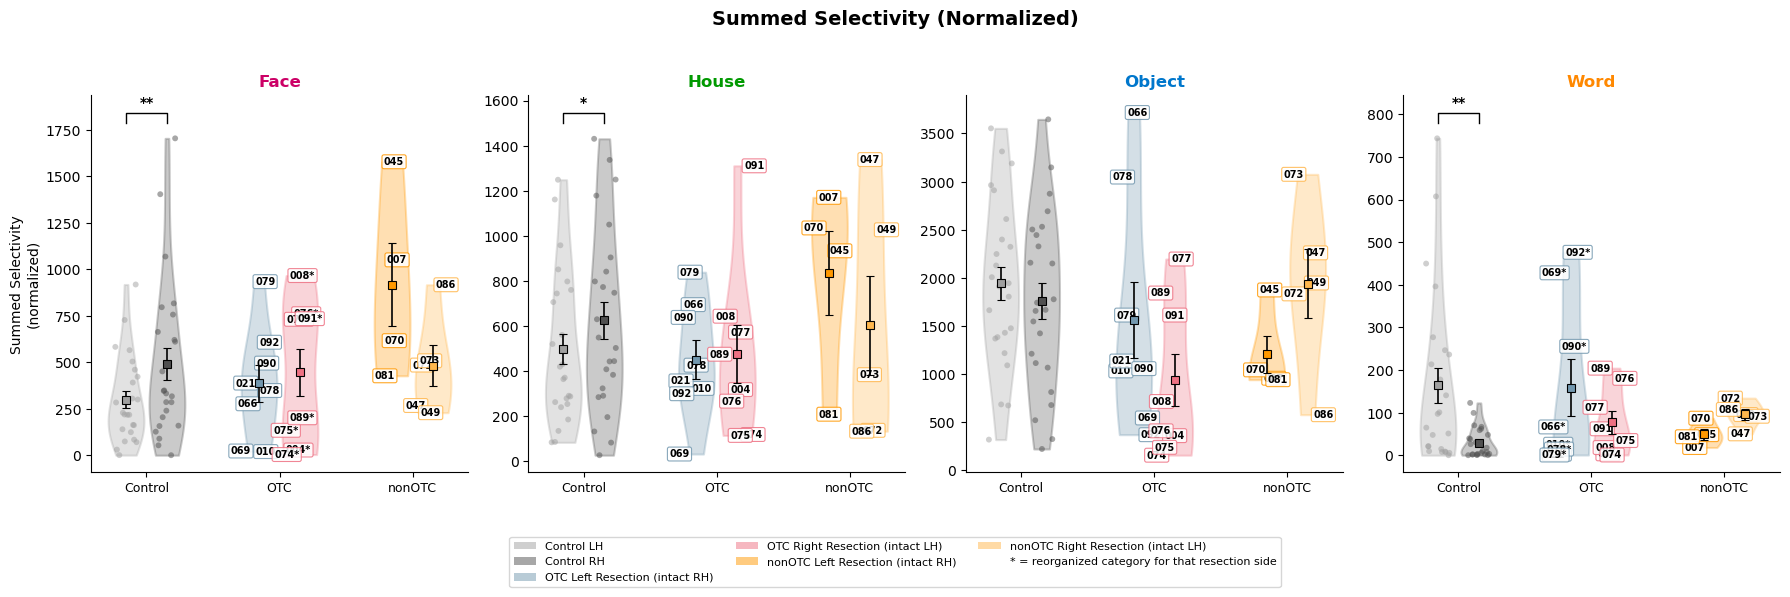

Saved: fig_selectivity_sum_selec_norm.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Figure — Summed Selectivity
# ═══════════════════════════════════════════════════════════════════════════════


METRIC = 'sum_selec_norm'
n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['sub'])
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── nonOTC Left/Right resection ───────────────────────────────────────
    for side, pos, fc in [('left', 2.6, NONOT), ('right', 3.0, '#FFB74D')]:
        sd = nonotc[(nonotc['category'] == cat) & (nonotc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(fc)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['sub'])
            ax.annotate(f'{lbl}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=fc, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=fc, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket (controls) ─────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        y_max = max(cl.max() if len(cl) > 0 else 0,
                    cr.max() if len(cr) > 0 else 0)
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y * 1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5, 2.8])
    ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Summed Selectivity\n(normalized)')

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Patch(facecolor=NONOT,  alpha=0.5, label='nonOTC Left Resection (intact RH)'),
    Patch(facecolor='#FFB74D', alpha=0.5, label='nonOTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Summed Selectivity (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_selectivity_{METRIC}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_selectivity_{METRIC}.png')

LONGITUDINAL SUMMED SELECTIVITY CHANGE (T2 - T1)

Controls:
  face left: ΔM=42.8 (SD=123.8), t(8)=-0.978, p=0.3566
  face right: ΔM=115.5 (SD=168.8), t(8)=-1.935, p=0.0890
  house left: ΔM=220.3 (SD=358.7), t(8)=-1.737, p=0.1206
  house right: ΔM=274.1 (SD=279.1), t(8)=-2.778, p=0.0240
  object left: ΔM=-120.2 (SD=1216.0), t(8)=0.280, p=0.7868
  object right: ΔM=-233.0 (SD=1185.1), t(8)=0.556, p=0.5934
  word left: ΔM=22.2 (SD=160.3), t(8)=-0.392, p=0.7051
  word right: ΔM=9.6 (SD=33.0), t(8)=-0.824, p=0.4336

OTC patients:
  sub-004 face [reorg]: Δ=+416, CI=[-63,137] **ABNORMAL**
  sub-004 house [reorg]: Δ=+411, CI=[-58,499] 
  sub-004 object [normal]: Δ=+749, CI=[-981,792] 
  sub-004 word [normal]: Δ=+94, CI=[-99,137] 
  sub-008 face [reorg]: Δ=-831, CI=[-63,137] **ABNORMAL**
  sub-008 house [reorg]: Δ=-556, CI=[-58,499] **ABNORMAL**
  sub-008 object [normal]: Δ=-696, CI=[-981,792] 
  sub-008 word [normal]: Δ=-2, CI=[-99,137] 
  sub-010 face [normal]: Δ=-2, CI=[0,256] **ABNORMAL**
  

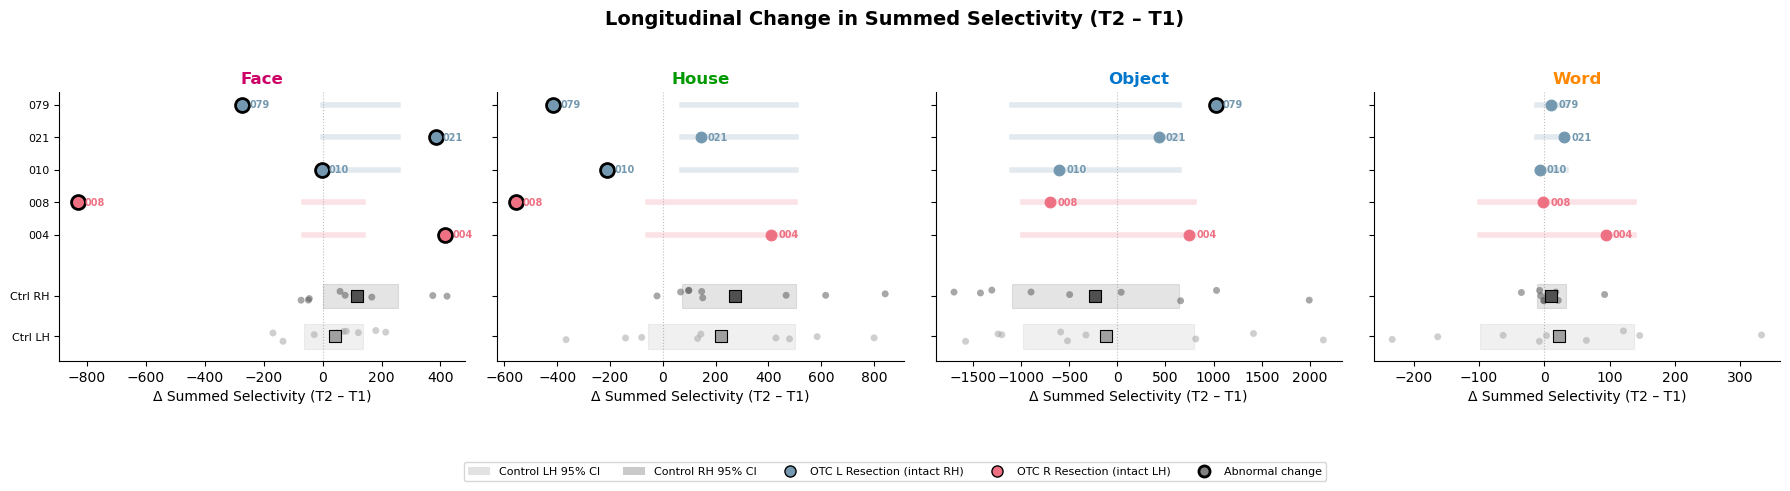

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8c: Longitudinal T1→T2 — Summed Selectivity Change Scores
# ═══════════════════════════════════════════════════════════════════════════════

# ── Rebuild ctrl_long with timepoint column (needed by this cell) ─────
_t1 = df_t1.copy(); _t1['timepoint'] = 'T1'
_tl = df_tl.copy(); _tl['timepoint'] = 'T2'
ctrl_long = pd.concat([_t1[_t1['group'] == 'control'], _tl[_tl['group'] == 'control']])
otc_long  = pd.concat([_t1[_t1['group'] == 'OTC'], _tl[_tl['group'] == 'OTC']])

METRIC_LONG = 'sum_selec_norm'
N_ITER = 10000
N_SUBS_BOOT = 4
rng = np.random.default_rng(42)

# ── Compute control change scores ─────────────────────────────────────────
ctrl_change_ss = {}
ctrl_change_details_ss = {}

for cat in CATEGORIES:
    for hemi in ['left', 'right']:
        t1 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi'] == hemi) &
                        (ctrl_long['timepoint'] == 'T1')][['sub', METRIC_LONG]].set_index('sub')
        t2 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi'] == hemi) &
                        (ctrl_long['timepoint'] == 'T2')][['sub', METRIC_LONG]].set_index('sub')
        paired = t1.join(t2, lsuffix='_t1', rsuffix='_t2').dropna()
        if len(paired) < 3:
            continue
        change = (paired[f'{METRIC_LONG}_t2'] - paired[f'{METRIC_LONG}_t1']).values
        ctrl_change_ss[f'{cat}_{hemi}'] = change
        ctrl_change_details_ss[f'{cat}_{hemi}'] = paired

# ── Bootstrap control change distributions ────────────────────────────────
boot_change_ss = {}
for key, changes in ctrl_change_ss.items():
    n_avail = len(changes)
    n_draw = min(N_SUBS_BOOT, n_avail)
    idx = np.array([rng.choice(n_avail, size=n_draw, replace=False) for _ in range(N_ITER)])
    boot_change_ss[key] = changes[idx].mean(axis=1)

# ── Compute OTC patient change scores ─────────────────────────────────────
pt_change_rows_ss = []
for sub in sorted(otc_long['sub'].unique()):
    sub_data = otc_long[otc_long['sub'] == sub]
    intact = sub_data['intact_hemi'].iloc[0]
    surgery_side = 'right' if intact == 'left' else 'left'

    for cat in CATEGORIES:
        t1_row = sub_data[(sub_data['category'] == cat) & (sub_data['timepoint'] == 'T1')]
        t2_row = sub_data[(sub_data['category'] == cat) & (sub_data['timepoint'] == 'T2')]
        if t1_row.empty or t2_row.empty:
            continue

        t1_val = t1_row[METRIC_LONG].values[0]
        t2_val = t2_row[METRIC_LONG].values[0]
        pt_ch = t2_val - t1_val

        boot_key = f'{cat}_{intact}'
        ci_lo = np.percentile(boot_change_ss[boot_key], 2.5) if boot_key in boot_change_ss else np.nan
        ci_hi = np.percentile(boot_change_ss[boot_key], 97.5) if boot_key in boot_change_ss else np.nan

        pref = PREFERRED_HEMI[cat]
        is_reorg = (intact != pref)

        pt_change_rows_ss.append({
            'sub': sub, 'intact_hemi': intact, 'surgery_side': surgery_side,
            'category': cat, 'change': pt_ch,
            'test_type': 'reorg' if is_reorg else 'normal',
            'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'abnormal': pt_ch < ci_lo or pt_ch > ci_hi,
        })

df_pt_change_ss = pd.DataFrame(pt_change_rows_ss)

# ── Print stats ───────────────────────────────────────────────────────────
print('='*70)
print(f'LONGITUDINAL SUMMED SELECTIVITY CHANGE (T2 - T1)')
print('='*70)

print('\nControls:')
for cat in CATEGORIES:
    for hemi in ['left', 'right']:
        key = f'{cat}_{hemi}'
        if key not in ctrl_change_ss:
            continue
        ch = ctrl_change_ss[key]
        t_stat, t_p = ttest_rel(
            ctrl_change_details_ss[key][f'{METRIC_LONG}_t1'].values,
            ctrl_change_details_ss[key][f'{METRIC_LONG}_t2'].values
        )
        print(f'  {cat} {hemi}: ΔM={ch.mean():.1f} (SD={ch.std():.1f}), '
              f't({len(ch)-1})={t_stat:.3f}, p={t_p:.4f}')

print('\nOTC patients:')
for _, r in df_pt_change_ss.iterrows():
    flag = '**ABNORMAL**' if r['abnormal'] else ''
    print(f'  {r["sub"]} {r["category"]} [{r["test_type"]}]: '
          f'Δ={r["change"]:+.0f}, CI=[{r["ci_lo"]:.0f},{r["ci_hi"]:.0f}] {flag}')

# ── Figure: Change score dot plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.5 * len(CATEGORIES), 4.5),
                          sharey=True)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]

    for hemi, color, y_base in [('left', CTRL_L, 0), ('right', CTRL_R, 1)]:
        key = f'{cat}_{hemi}'
        if key not in ctrl_change_ss:
            continue

        changes = ctrl_change_ss[key]
        ci_lo = np.percentile(boot_change_ss[key], 2.5)
        ci_hi = np.percentile(boot_change_ss[key], 97.5)

        ax.barh(y_base, ci_hi - ci_lo, left=ci_lo, height=0.6,
                color=color, alpha=0.15, edgecolor=color, linewidth=0.8)
        jit = RNG.uniform(-0.15, 0.15, len(changes))
        ax.scatter(changes, np.full(len(changes), y_base) + jit,
                   color=color, alpha=0.5, s=25, zorder=3, edgecolors='none')
        ax.scatter(changes.mean(), y_base, color=color, s=80, marker='s',
                   edgecolors='black', linewidth=0.8, zorder=5)

    pt_cat = df_pt_change_ss[df_pt_change_ss['category'] == cat]
    for i, (_, r) in enumerate(pt_cat.iterrows()):
        y_pos = 2.5 + i * 0.8
        pt_color = OTC_L if r['surgery_side'] == 'left' else OTC_R

        marker_size = 100 if r['abnormal'] else 60
        edge = 'black' if r['abnormal'] else pt_color
        edge_w = 2.0 if r['abnormal'] else 0.8

        ax.scatter(r['change'], y_pos, color=pt_color, s=marker_size,
                   edgecolors=edge, linewidth=edge_w, zorder=5)
        ax.annotate(short_name(r['sub']),
                    (r['change'], y_pos), fontsize=7, fontweight='bold',
                    xytext=(5, 0), textcoords='offset points',
                    va='center', color=pt_color, zorder=6)

        boot_key = f'{cat}_{r["intact_hemi"]}'
        if boot_key in boot_change_ss:
            ci_lo = np.percentile(boot_change_ss[boot_key], 2.5)
            ci_hi = np.percentile(boot_change_ss[boot_key], 97.5)
            ax.plot([ci_lo, ci_hi], [y_pos, y_pos],
                    color=pt_color, alpha=0.2, linewidth=4, zorder=1)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold', color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('')
    ax.set_xlabel('Δ Summed Selectivity (T2 – T1)')

    yticks = [0, 1] + [2.5 + i * 0.8 for i in range(len(pt_cat))]
    ylabels = ['Ctrl LH', 'Ctrl RH'] + [short_name(r['sub']) for _, r in pt_cat.iterrows()]
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)

legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.3, label='Control LH 95% CI'),
    Patch(facecolor=CTRL_R, alpha=0.3, label='Control RH 95% CI'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_L,
           markersize=8, label='OTC L Resection (intact RH)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_R,
           markersize=8, label='OTC R Resection (intact LH)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray',
           markeredgecolor='black', markeredgewidth=2, markersize=8,
           label='Abnormal change'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Longitudinal Change in Summed Selectivity (T2 – T1)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_longitudinal_change_sum_selec_norm.png'),
            dpi=300, bbox_inches='tight')
plt.show()

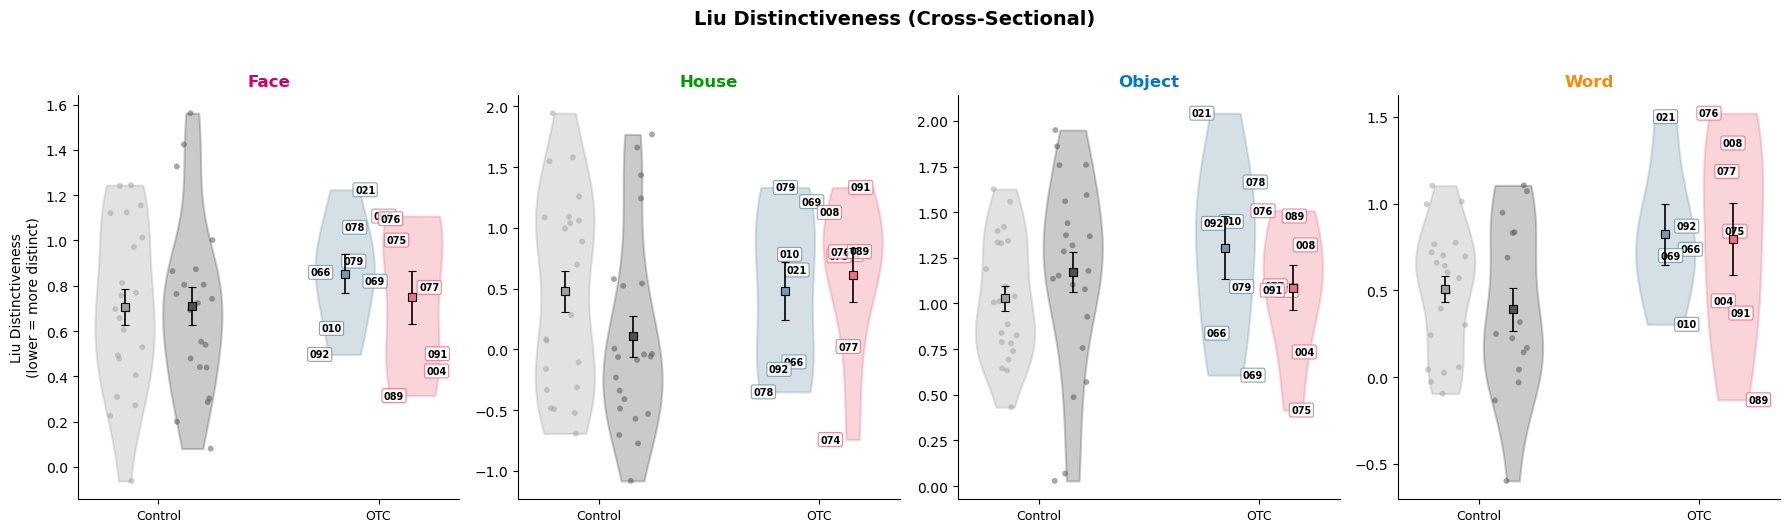

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Figure — Cross-Sectional Liu Distinctiveness
# ═══════════════════════════════════════════════════════════════════════════════

VCOL = 'liu_distinctiveness'
ctrl_liu = df_liu_cs[df_liu_cs['status'] == 'control']
otc_liu  = df_liu_cs[df_liu_cs['group'] == 'OTC']

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.5 * len(CATEGORIES), 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []
    for hemi, pos, color in [('left', 0.0, CTRL_L), ('right', 0.4, CTRL_R)]:
        vals = ctrl_liu[(ctrl_liu['category'] == cat) & (ctrl_liu['hemi_label'] == hemi)][VCOL].values
        if len(vals) < 2: continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    otc_cat = otc_liu[(otc_liu['category'] == cat) & (otc_liu['hemi_label'] == 'intact')]
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        if 'surgery_side' not in otc_cat.columns: continue
        sd = otc_cat[otc_cat['surgery_side'] == side]
        vals = sd[VCOL].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            ax.annotate(short_name(row['subject_id']), (pos + jit, row[VCOL]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8), zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(max(len(vals),1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False, showmedians=False,
                              showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    ax.set_xticks([0.2, 1.5])
    ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold', color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Liu Distinctiveness\n(lower = more distinct)')

plt.suptitle('Liu Distinctiveness (Cross-Sectional)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig(str(FIG_DIR / 'fig_liu_distinctiveness_cs.png'), dpi=300, bbox_inches='tight')
plt.show()

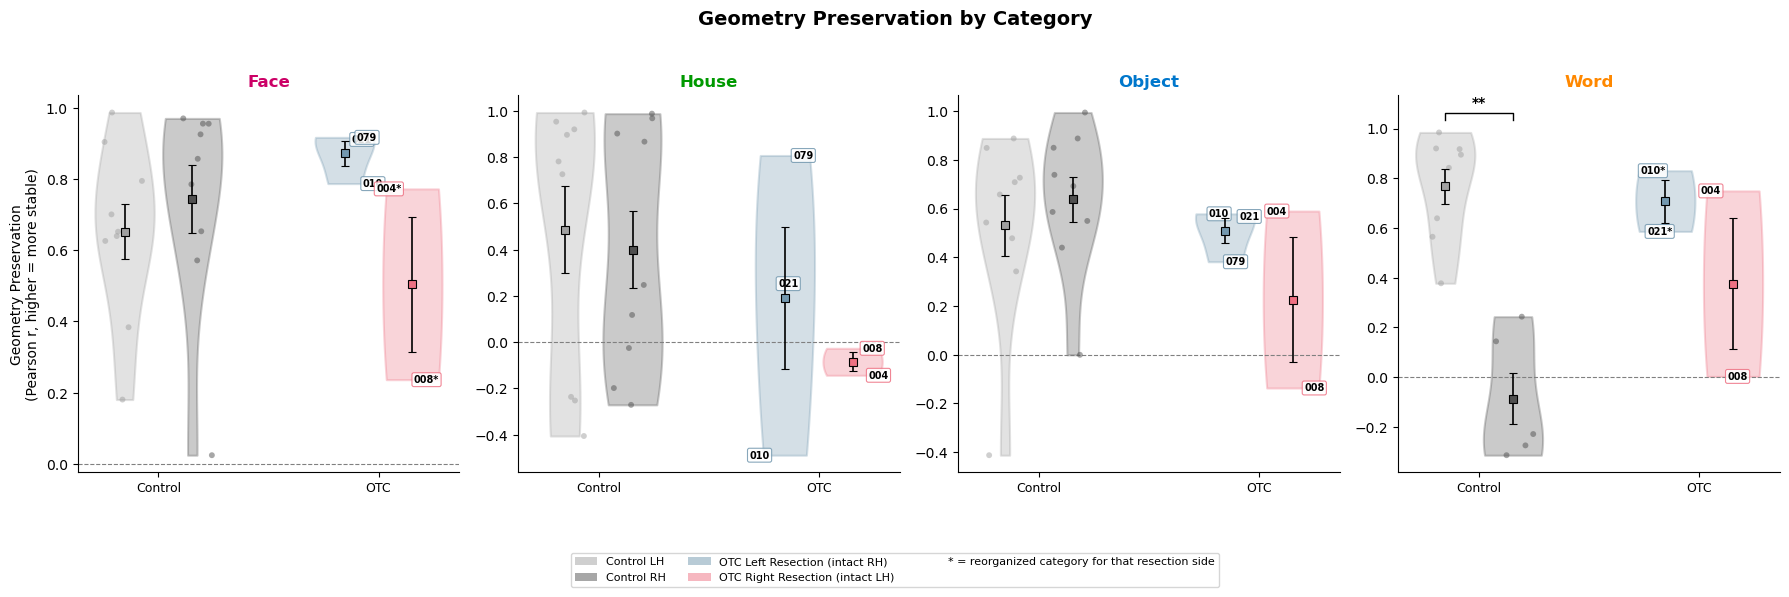

Saved: fig_geometry_by_category_differential.png


In [11]:
# CELL 7: Figure — Geometry Preservation by Category
# ═══════════════════════════════════════════════════════════════════════════════
# Violin + jitter for controls LH/RH, labeled badges for OTC patients.
# Same layout as selectivity and Liu distinctiveness figures.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Geometry-specific setup (rebind ctrl/otc for this cell) ───────────
METRIC = 'geometry_preservation'
ctrl = df_geo[df_geo['status'] == 'control'].copy()
otc  = df_geo[(df_geo['group'] == 'OTC') & (df_geo['hemi_label'] == 'intact')].copy()
if 'intact_hemi' not in otc.columns:
    otc['intact_hemi'] = otc['surgery_side'].map(lambda s: 'right' if s == 'left' else 'left')

# Lateralization for geometry
ctrl_wide = {}
lat_results = {}
for cat in CATEGORIES:
    piv = ctrl[ctrl['category'] == cat][['subject_id', 'hemi_label', METRIC]].pivot(
        index='subject_id', columns='hemi_label', values=METRIC).dropna()
    ctrl_wide[cat] = piv
    if len(piv) >= 3:
        from scipy.stats import ttest_rel
        t, p = ttest_rel(piv['left'].values, piv['right'].values)
        lat_results[cat] = {'t': t, 'p': p, 'sig': p < 0.05 / len(CATEGORIES)}


n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['subject'])
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket ────────────────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        all_vals = np.concatenate([cl, cr]) if len(cl) > 0 and len(cr) > 0 else np.array([0])
        y_max = all_vals.max()
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y * 1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5])
    ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
    if col_idx == 0:
        ax.set_ylabel('Geometry Preservation\n(Pearson r, higher = more stable)')

legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Geometry Preservation by Category', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_geometry_by_category_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_geometry_by_category_{COPE_SET}.png')

ASYMMETRIC vs SYMMETRIC GEOMETRY
  Asymmetric = face, word (unilateral)
  Symmetric  = house, object (bilateral)
  diff = symmetric - asymmetric (negative = symmetric worse)

OTC (n=5):
  Asymmetric: M=0.671 (SD=0.315)
  Symmetric:  M=0.238 (SD=0.272)
  Diff (sym-asym): M=-0.432 (SD=0.221)
  Paired t(4)=-4.378, p=0.0119, d=-1.958

  Per patient:
    OTC004: asym=0.760, sym=0.223, diff=-0.537 ↓
    OTC008: asym=0.119, sym=-0.082, diff=-0.201 ↓
    OTC010: asym=0.808, sym=0.045, diff=-0.764 ↓
    OTC021: asym=0.748, sym=0.410, diff=-0.338 ↓
    OTC079: asym=0.917, sym=0.594, diff=-0.322 ↓

Controls (n=9):
  Asymmetric: M=0.584 (SD=0.197)
  Symmetric:  M=0.513 (SD=0.291)
  Diff (sym-asym): M=-0.071 (SD=0.256)
  Paired t(8)=-0.830, p=0.4304, d=-0.277

Difference-of-differences (OTC diff - Control diff):
  OTC diff:     -0.432
  Control diff: -0.071
  Diff-of-diff: -0.362  95% CI [-0.602, -0.134]
  → SIGNIFICANT


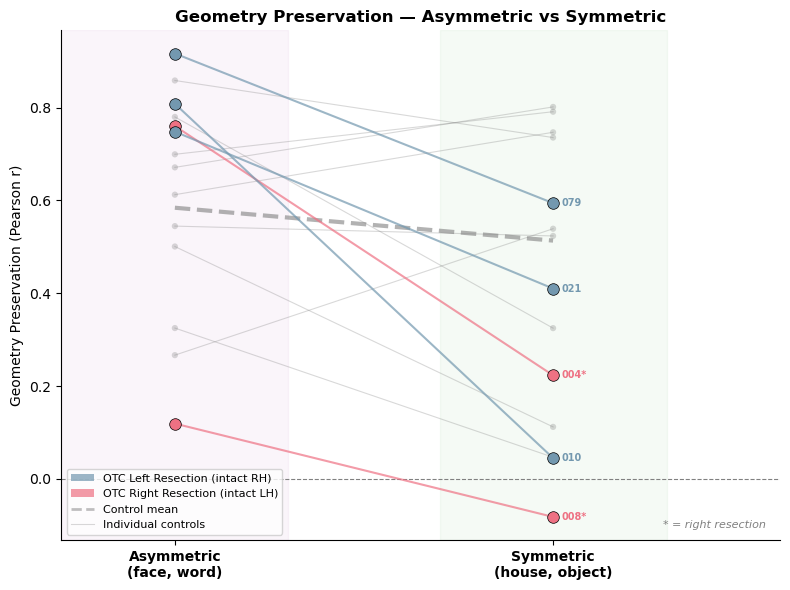

Saved: fig_geometry_slope_differential.png


In [12]:
# CELL 8: Figure — Symmetric vs Asymmetric Slope Plot
# ═══════════════════════════════════════════════════════════════════════════════
# Paired slope: asymmetric (face, word) mean → symmetric (house, object) mean
# per patient. This is the headline visualization.
#
# Also computes the asymmetric–symmetric difference for each patient and
# bootstraps the group difference.
# ═══════════════════════════════════════════════════════════════════════════════

# Compute per-patient asymmetric and symmetric means
# ── Geometry-specific setup (rebind ctrl/otc for this cell) ───────────
METRIC = 'geometry_preservation'
ctrl = df_geo[df_geo['status'] == 'control'].copy()
otc  = df_geo[(df_geo['group'] == 'OTC') & (df_geo['hemi_label'] == 'intact')].copy()
if 'intact_hemi' not in otc.columns:
    otc['intact_hemi'] = otc['surgery_side'].map(lambda s: 'right' if s == 'left' else 'left')

# Lateralization for geometry
ctrl_wide = {}
lat_results = {}
for cat in CATEGORIES:
    piv = ctrl[ctrl['category'] == cat][['subject_id', 'hemi_label', METRIC]].pivot(
        index='subject_id', columns='hemi_label', values=METRIC).dropna()
    ctrl_wide[cat] = piv
    if len(piv) >= 3:
        from scipy.stats import ttest_rel
        t, p = ttest_rel(piv['left'].values, piv['right'].values)
        lat_results[cat] = {'t': t, 'p': p, 'sig': p < 0.05 / len(CATEGORIES)}


slope_rows = []
for sub in sorted(otc['subject_id'].unique()):
    sub_df = otc[otc['subject_id'] == sub]
    sub_code = sub_df['subject'].iloc[0]
    side = sub_df['surgery_side'].iloc[0]

    asym_vals = [sub_df[sub_df['category'] == c][METRIC].values for c in UNILATERAL]
    sym_vals  = [sub_df[sub_df['category'] == c][METRIC].values for c in BILATERAL]

    asym = np.nanmean([v[0] for v in asym_vals if len(v)])
    sym  = np.nanmean([v[0] for v in sym_vals if len(v)])

    if np.isfinite(asym) and np.isfinite(sym):
        slope_rows.append({
            'subject': sub_code, 'surgery_side': side,
            'asymmetric': asym, 'symmetric': sym,
            'diff': sym - asym,  # negative = symmetric worse
        })

df_slope = pd.DataFrame(slope_rows)

# Same for controls (average across L and R hemispheres first, then asym/sym)
ctrl_slope_rows = []
for sub in sorted(ctrl['subject_id'].unique()):
    sub_df = ctrl[ctrl['subject_id'] == sub]

    asym_vals = []
    for c in UNILATERAL:
        cv = sub_df[sub_df['category'] == c][METRIC].values
        if len(cv) > 0:
            asym_vals.append(cv.mean())  # average across hemispheres
    sym_vals = []
    for c in BILATERAL:
        cv = sub_df[sub_df['category'] == c][METRIC].values
        if len(cv) > 0:
            sym_vals.append(cv.mean())

    if len(asym_vals) > 0 and len(sym_vals) > 0:
        asym = np.mean(asym_vals)
        sym  = np.mean(sym_vals)
        ctrl_slope_rows.append({
            'subject': sub_df['subject'].iloc[0],
            'asymmetric': asym, 'symmetric': sym,
            'diff': sym - asym,
        })

df_ctrl_slope = pd.DataFrame(ctrl_slope_rows)

# ── Statistics ────────────────────────────────────────────────────────────
print('='*70)
print('ASYMMETRIC vs SYMMETRIC GEOMETRY')
print('  Asymmetric = face, word (unilateral)')
print('  Symmetric  = house, object (bilateral)')
print('  diff = symmetric - asymmetric (negative = symmetric worse)')
print('='*70)

if len(df_slope) > 0:
    print(f'\nOTC (n={len(df_slope)}):')
    print(f'  Asymmetric: M={df_slope["asymmetric"].mean():.3f} (SD={df_slope["asymmetric"].std():.3f})')
    print(f'  Symmetric:  M={df_slope["symmetric"].mean():.3f} (SD={df_slope["symmetric"].std():.3f})')
    print(f'  Diff (sym-asym): M={df_slope["diff"].mean():.3f} (SD={df_slope["diff"].std():.3f})')
    # Paired t-test
    t, p = ttest_rel(df_slope['symmetric'].values, df_slope['asymmetric'].values)
    d = df_slope['diff'].mean() / df_slope['diff'].std() if df_slope['diff'].std() > 0 else np.nan
    print(f'  Paired t({len(df_slope)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

    # Per patient
    print(f'\n  Per patient:')
    for _, r in df_slope.iterrows():
        direction = '↓' if r['diff'] < 0 else '↑'
        print(f'    {r["subject"]}: asym={r["asymmetric"]:.3f}, sym={r["symmetric"]:.3f}, '
              f'diff={r["diff"]:+.3f} {direction}')

if len(df_ctrl_slope) > 0:
    print(f'\nControls (n={len(df_ctrl_slope)}):')
    print(f'  Asymmetric: M={df_ctrl_slope["asymmetric"].mean():.3f} (SD={df_ctrl_slope["asymmetric"].std():.3f})')
    print(f'  Symmetric:  M={df_ctrl_slope["symmetric"].mean():.3f} (SD={df_ctrl_slope["symmetric"].std():.3f})')
    print(f'  Diff (sym-asym): M={df_ctrl_slope["diff"].mean():.3f} (SD={df_ctrl_slope["diff"].std():.3f})')
    t, p = ttest_rel(df_ctrl_slope['symmetric'].values, df_ctrl_slope['asymmetric'].values)
    d = df_ctrl_slope['diff'].mean() / df_ctrl_slope['diff'].std() if df_ctrl_slope['diff'].std() > 0 else np.nan
    print(f'  Paired t({len(df_ctrl_slope)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

# ── Bootstrap difference-of-differences ───────────────────────────────────
if len(df_slope) > 0 and len(df_ctrl_slope) > 0:
    otc_diffs  = df_slope['diff'].values
    ctrl_diffs = df_ctrl_slope['diff'].values

    rng_dd = np.random.default_rng(42)
    n_boot_dd = 100000
    boot_dd = np.empty(n_boot_dd)
    for i in range(n_boot_dd):
        otc_sample  = rng_dd.choice(otc_diffs, size=len(otc_diffs), replace=True)
        ctrl_sample = rng_dd.choice(ctrl_diffs, size=len(ctrl_diffs), replace=True)
        boot_dd[i]  = otc_sample.mean() - ctrl_sample.mean()

    dd_mean = otc_diffs.mean() - ctrl_diffs.mean()
    dd_ci   = np.percentile(boot_dd, [2.5, 97.5])
    sig     = 'SIGNIFICANT' if dd_ci[0] > 0 or dd_ci[1] < 0 else 'not significant'

    print(f'\nDifference-of-differences (OTC diff - Control diff):')
    print(f'  OTC diff:     {otc_diffs.mean():.3f}')
    print(f'  Control diff: {ctrl_diffs.mean():.3f}')
    print(f'  Diff-of-diff: {dd_mean:.3f}  95% CI [{dd_ci[0]:.3f}, {dd_ci[1]:.3f}]')
    print(f'  → {sig}')

# ── Slope Figure ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Plot control slopes (gray, background)
for _, r in df_ctrl_slope.iterrows():
    ax.plot([0, 1], [r['asymmetric'], r['symmetric']],
            color='gray', linewidth=0.8, alpha=0.3, zorder=1)
    ax.scatter([0, 1], [r['asymmetric'], r['symmetric']],
               color='gray', s=20, alpha=0.3, zorder=1, edgecolors='none')

# Control group mean
if len(df_ctrl_slope) > 0:
    ax.plot([0, 1],
            [df_ctrl_slope['asymmetric'].mean(), df_ctrl_slope['symmetric'].mean()],
            color='gray', linewidth=3, alpha=0.6, zorder=2, linestyle='--')

# Plot OTC slopes
for _, r in df_slope.iterrows():
    col = OTC_L if r['surgery_side'] == 'left' else OTC_R
    lbl = short_name(r['subject'])
    star = '*' if r['surgery_side'] == 'right' else ''

    ax.plot([0, 1], [r['asymmetric'], r['symmetric']],
            color=col, linewidth=1.5, alpha=0.7, zorder=3)
    ax.scatter(0, r['asymmetric'], color=col, s=70, zorder=4,
               edgecolors='black', linewidth=0.5)
    ax.scatter(1, r['symmetric'], color=col, s=70, zorder=4,
               edgecolors='black', linewidth=0.5)
    ax.annotate(f'{lbl}{star}', (1, r['symmetric']),
                fontsize=7, fontweight='bold', ha='left', va='center',
                xytext=(6, 0), textcoords='offset points', color=col)

# Shading
ax.axvspan(-0.3, 0.3, alpha=0.04, color='purple', zorder=0)
ax.axvspan(0.7, 1.3, alpha=0.04, color='green', zorder=0)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Asymmetric\n(face, word)',
                     'Symmetric\n(house, object)'],
                    fontsize=10, fontweight='bold')
ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=10)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlim(-0.3, 1.6)
ax.set_title('Geometry Preservation — Asymmetric vs Symmetric',
             fontsize=12, fontweight='bold')

legend_elements = [
    Patch(facecolor=OTC_L, alpha=0.7, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R, alpha=0.7, label='OTC Right Resection (intact LH)'),
    Line2D([0], [0], color='gray', linewidth=2, alpha=0.5,
           linestyle='--', label='Control mean'),
    Line2D([0], [0], color='gray', linewidth=0.8, alpha=0.3,
           label='Individual controls'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, frameon=True)

ax.annotate('* = right resection', xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(str(FIG_DIR / f'fig_geometry_slope_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_geometry_slope_{COPE_SET}.png')

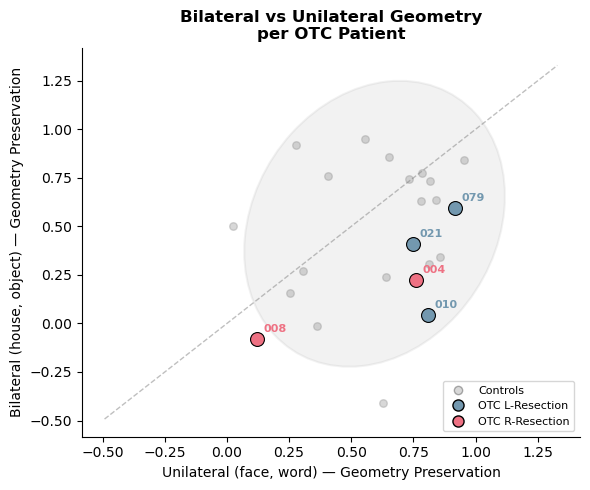

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Figure — Per-Patient Bilateral vs Unilateral Scatter
# ═══════════════════════════════════════════════════════════════════════════════

# ── Restore selectivity variables ─────────────────────────────────────
ctrl = df_sel_cs[df_sel_cs['group'] == 'control'].copy()
otc  = df_sel_cs[df_sel_cs['group'] == 'OTC'].copy()
otc['surgery_side'] = otc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

VCOL = 'geometry_preservation'
otc_geo = df_geo[(df_geo['group'] == 'OTC') & (df_geo['hemi_label'] == 'intact')]
ctrl_geo = df_geo[df_geo['status'] == 'control']

fig, ax = plt.subplots(figsize=(6, 5))

for sub in sorted(otc_geo['subject_id'].unique()):
    sd = otc_geo[otc_geo['subject_id'] == sub]
    surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else 'na'
    color = OTC_L if surgery == 'left' else OTC_R
    uni = sd[sd['category'].isin(UNILATERAL)][VCOL].mean()
    bi  = sd[sd['category'].isin(BILATERAL)][VCOL].mean()
    if np.isfinite(uni) and np.isfinite(bi):
        ax.scatter(uni, bi, color=color, s=100, zorder=5, edgecolors='black', linewidth=0.8)
        ax.annotate(short_name(sd['subject'].iloc[0] if 'subject' in sd.columns else sub),
                    (uni, bi), fontsize=8, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points', color=color)

ctrl_uni, ctrl_bi = [], []
for sub in ctrl_geo['subject_id'].unique():
    for hemi in ['left', 'right']:
        sd = ctrl_geo[(ctrl_geo['subject_id'] == sub) & (ctrl_geo['hemi_label'] == hemi)]
        u = sd[sd['category'].isin(UNILATERAL)][VCOL].mean()
        b = sd[sd['category'].isin(BILATERAL)][VCOL].mean()
        if np.isfinite(u) and np.isfinite(b):
            ctrl_uni.append(u); ctrl_bi.append(b)

ax.scatter(ctrl_uni, ctrl_bi, color='gray', alpha=0.3, s=30, zorder=2)
if len(ctrl_uni) >= 3:
    confidence_ellipse(np.array(ctrl_uni), np.array(ctrl_bi), ax, n_std=2.0,
                       facecolor='gray', alpha=0.1, edgecolor='gray', linewidth=1.5)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, linewidth=1)
ax.set_xlabel('Unilateral (face, word) — Geometry Preservation')
ax.set_ylabel('Bilateral (house, object) — Geometry Preservation')
ax.set_title('Bilateral vs Unilateral Geometry\nper OTC Patient', fontsize=12, fontweight='bold')
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', alpha=0.3, markersize=6, label='Controls'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_L, markeredgecolor='black', markersize=8, label='OTC L-Resection'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_R, markeredgecolor='black', markersize=8, label='OTC R-Resection'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'fig_bilateral_vs_unilateral_geometry.png'), dpi=300, bbox_inches='tight')
plt.show()

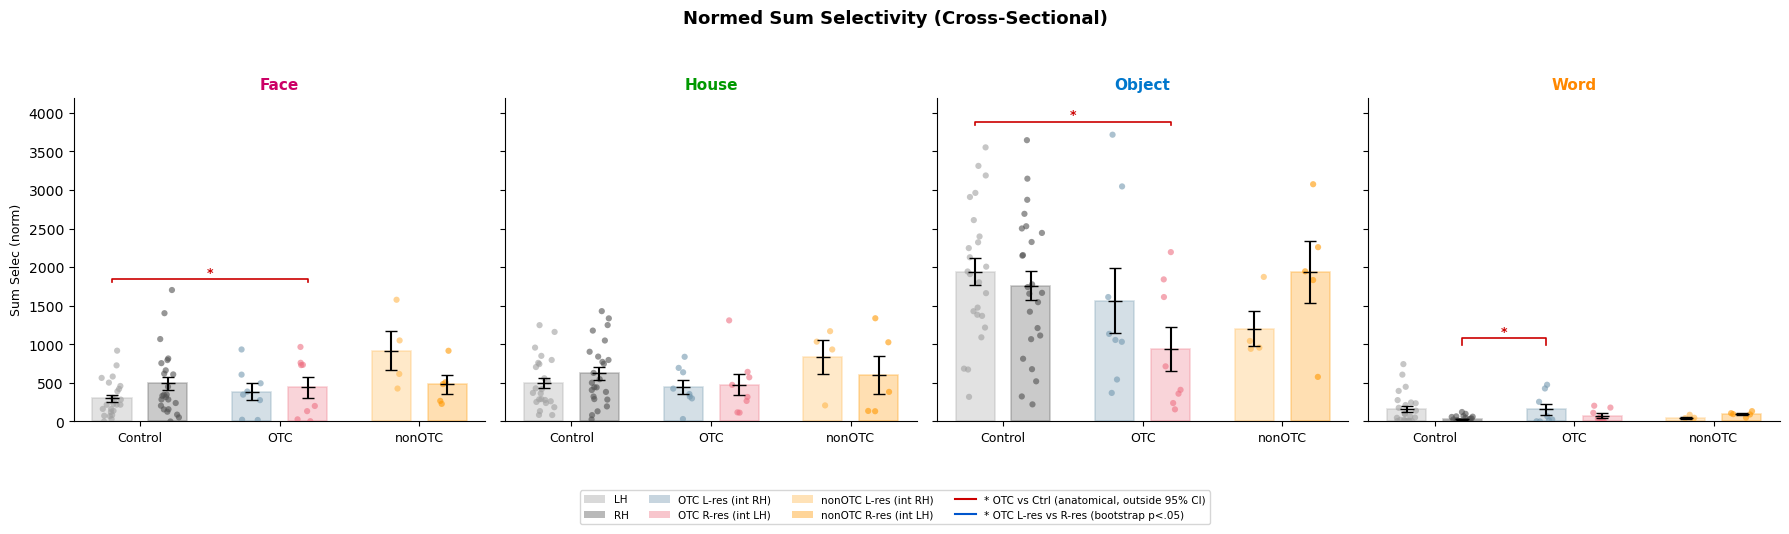

Saved: overview_sum_selec.png


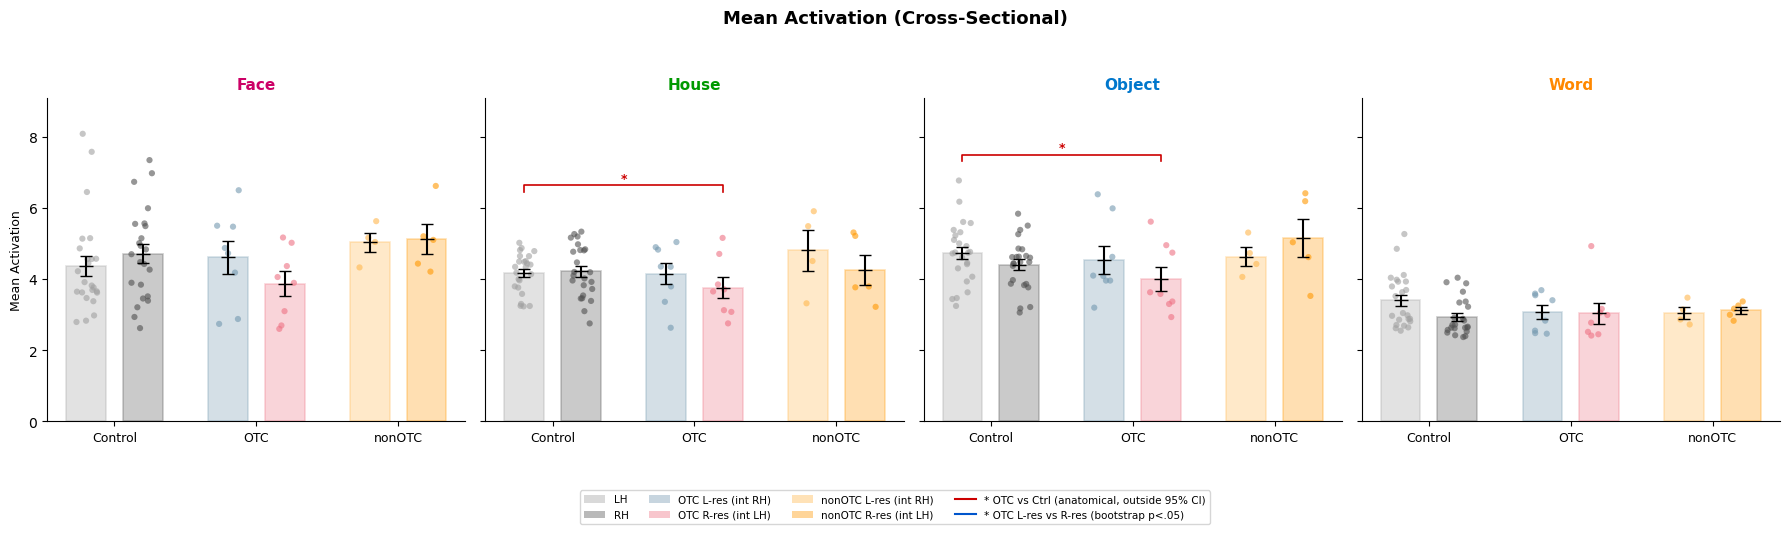

Saved: overview_mean_act.png


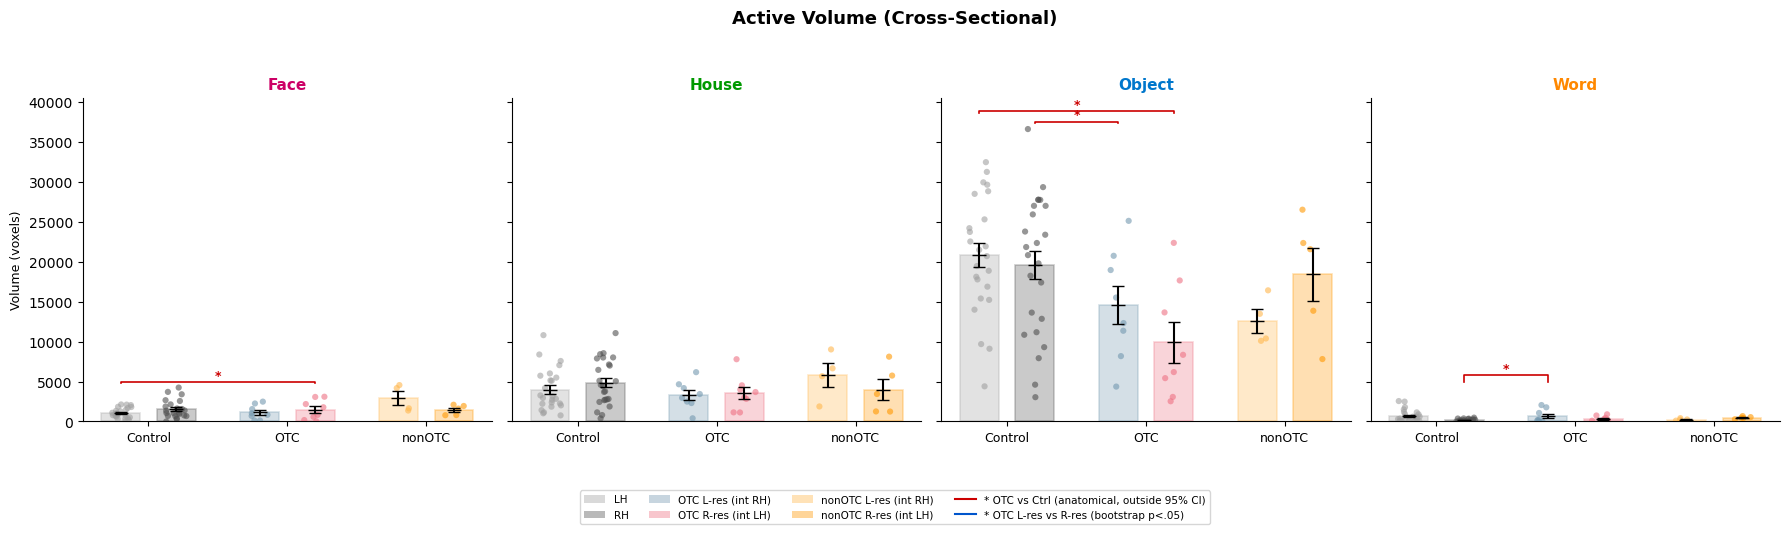

Saved: overview_volume.png


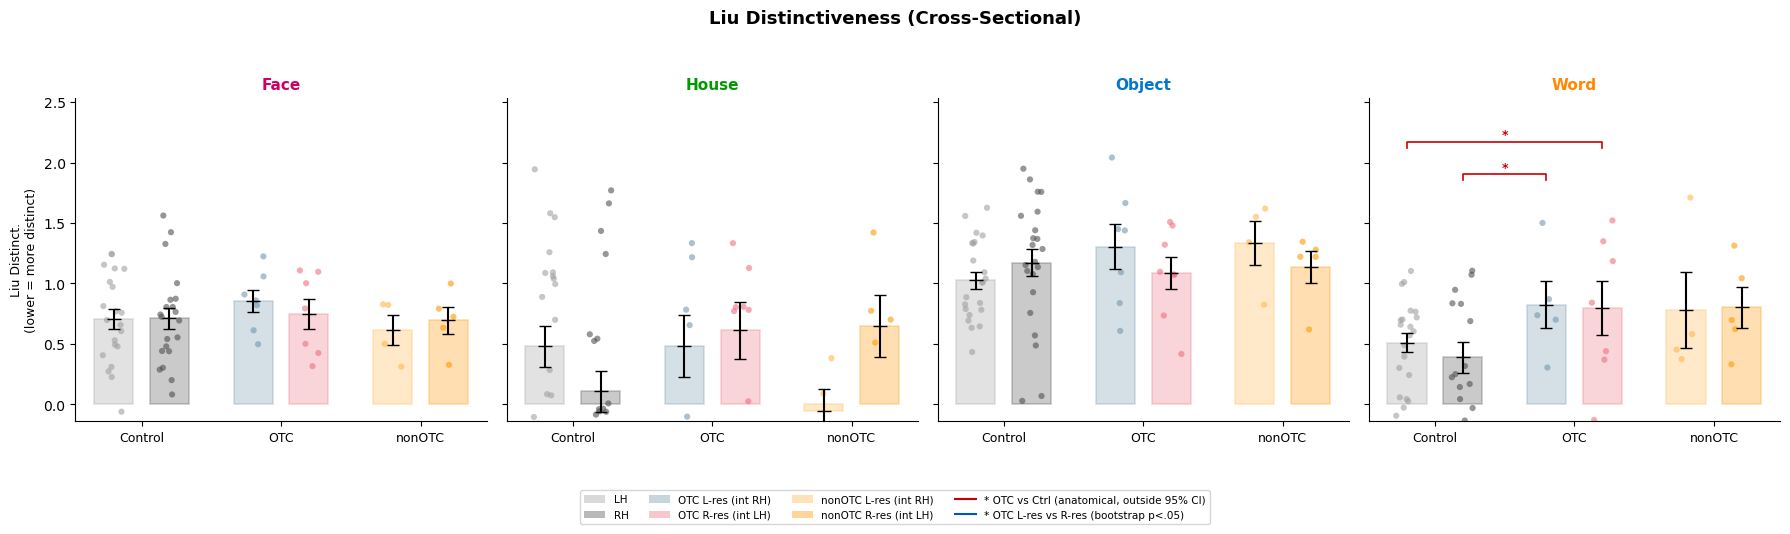

Saved: overview_liu_cs.png


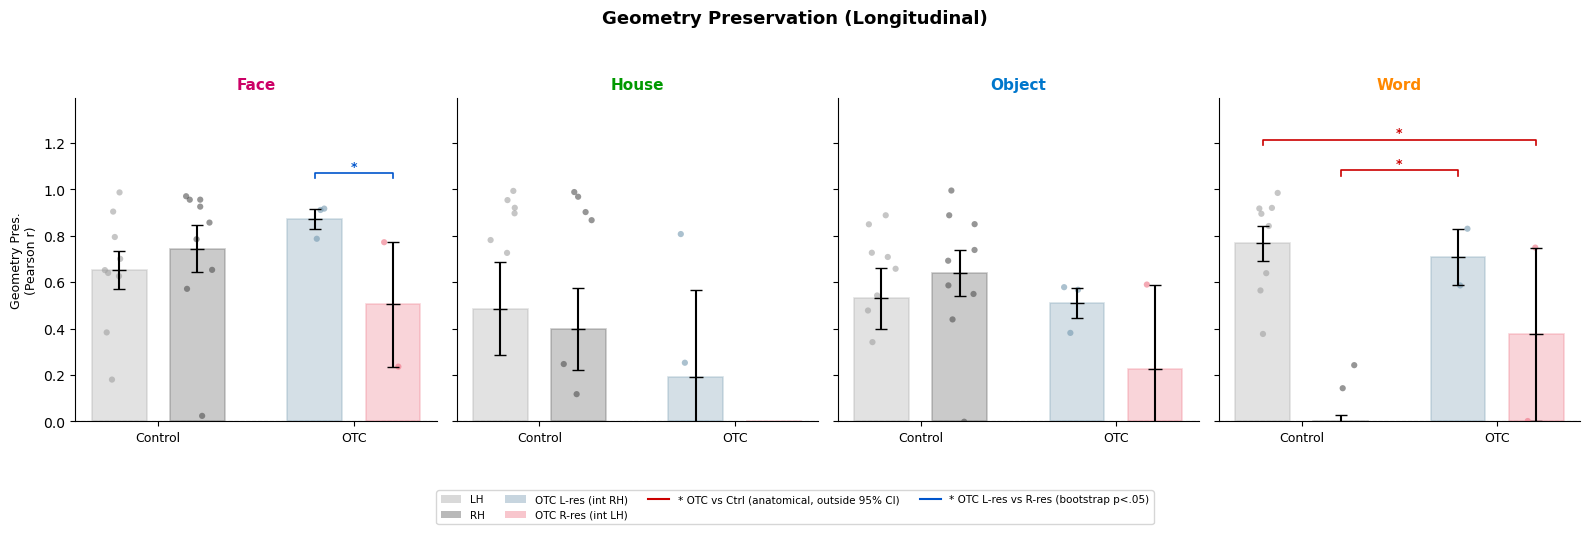

Saved: overview_geometry.png


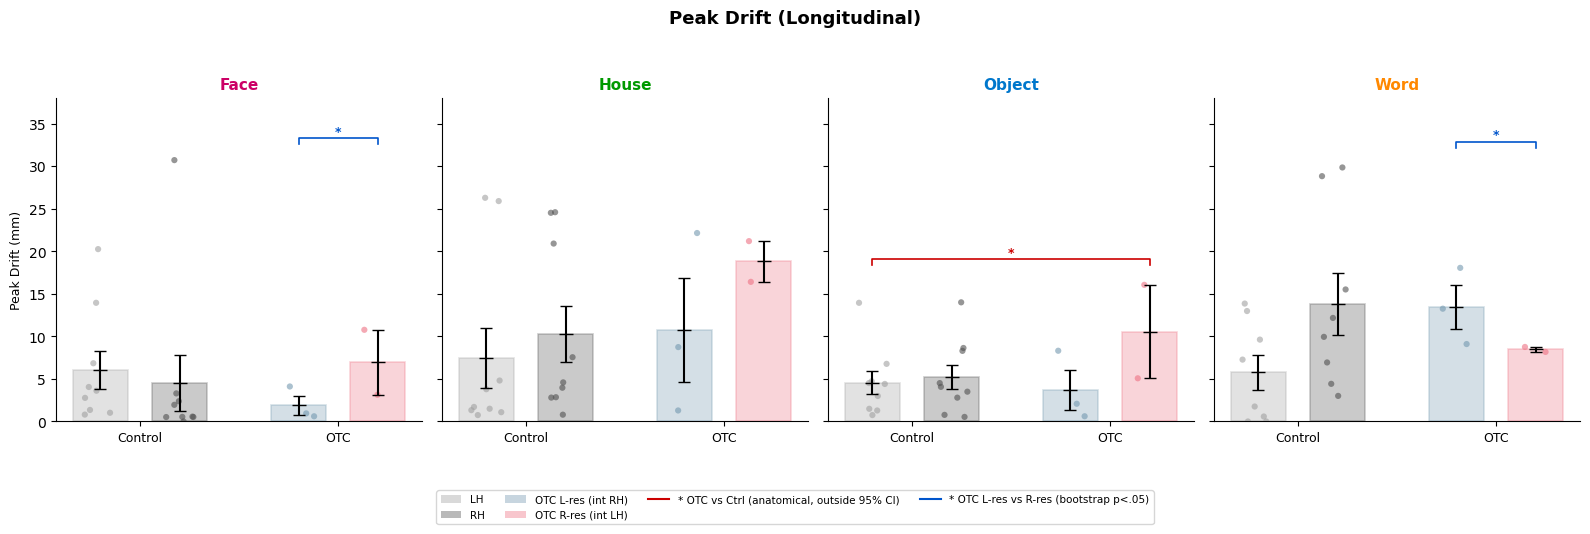

Saved: overview_peak_drift.png


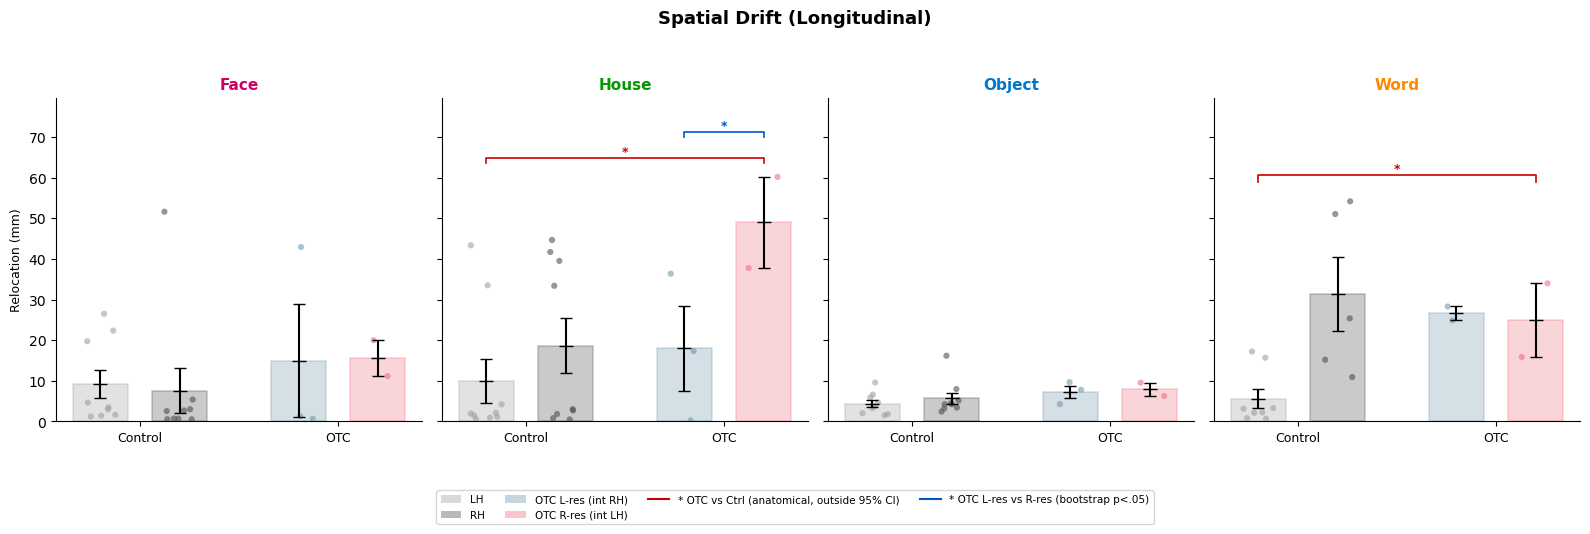

Saved: overview_spatial_drift.png


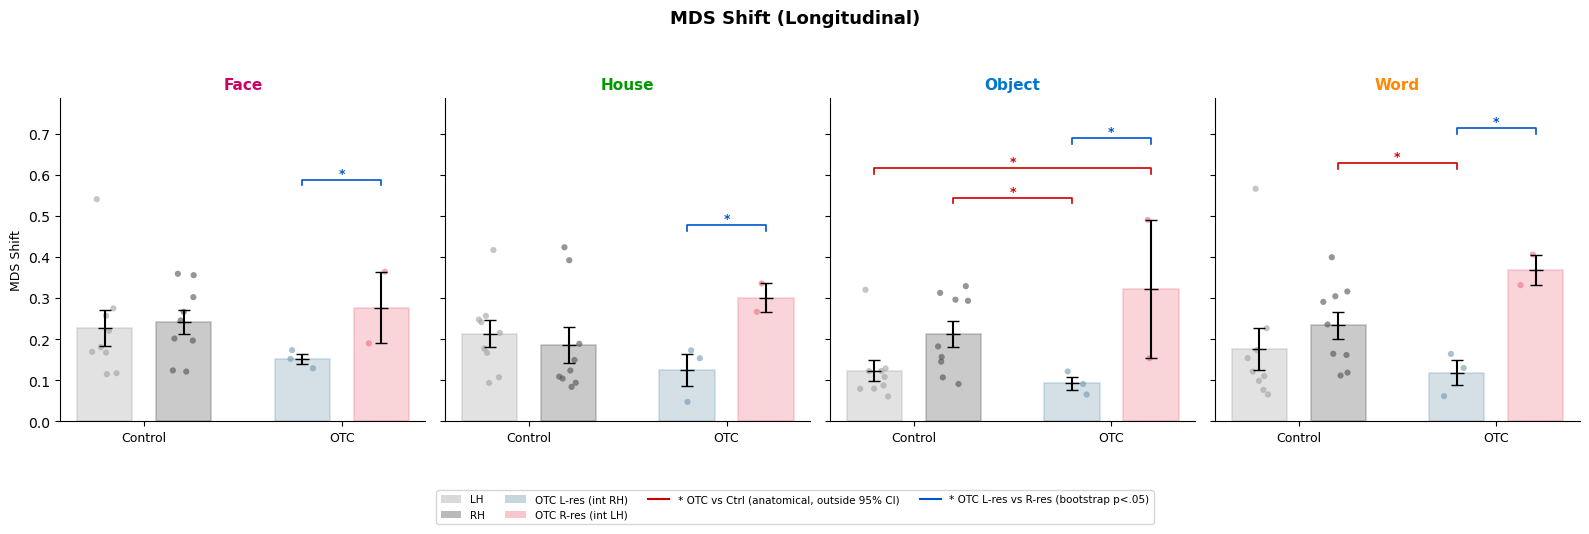

Saved: overview_mds_shift.png

All overview figures generated.


In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Standardized Measure Overview
# ═══════════════════════════════════════════════════════════════════════════════
# Bar + dot plot for every measure. Controls LH/RH, OTC L-res/R-res.
# Cross-sectional measures also show nonOTC.
# Significance brackets:
#   1) OTC vs matched control (anatomical: L-res vs Ctrl RH, R-res vs Ctrl LH)
#   2) OTC L-res vs OTC R-res within each category
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci_quick(vals, n_draw=None, n_iter=10000, rng=RNG):
    """Quick bootstrap CI for significance testing."""
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 3: return np.nan, np.nan
    if n_draw is None: n_draw = len(v)
    n_draw = min(n_draw, len(v))
    boot = np.array([rng.choice(v, size=n_draw, replace=False).mean() for _ in range(n_iter)])
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)


def bootstrap_p_quick(g1, g2, n_iter=10000, rng=RNG):
    """Two-sided bootstrap permutation test on difference of means."""
    g1 = np.asarray(g1, dtype=float); g1 = g1[np.isfinite(g1)]
    g2 = np.asarray(g2, dtype=float); g2 = g2[np.isfinite(g2)]
    if len(g1) < 2 or len(g2) < 2: return np.nan
    obs = np.mean(g1) - np.mean(g2)
    diffs = np.array([rng.choice(g1, len(g1), replace=True).mean() -
                       rng.choice(g2, len(g2), replace=True).mean()
                       for _ in range(n_iter)])
    centered = diffs - diffs.mean()
    return float(np.mean(np.abs(centered) >= np.abs(obs)))


def extract_measure(df, cat, vcol, schema='sel', include_nonotc=False, nonotc_df=None):
    """Extract Ctrl LH, Ctrl RH, OTC intact-RH (L-res), OTC intact-LH (R-res).
    Optionally nonOTC intact-LH and intact-RH.
    """
    c = df[df['category'] == cat] if 'category' in df.columns else df[df['measured_category'] == cat]
    out = {}
    if schema == 'sel':
        out['ctrl_lh'] = c[(c['group'] == 'control') & (c['hemi'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['group'] == 'control') & (c['hemi'] == 'right')][vcol].dropna().values
        otc_all = c[c['group'] == 'OTC']
        otc_intact = otc_all[otc_all['hemi'] == otc_all['intact_hemi']]
        out['otc_rh'] = otc_intact[otc_intact['intact_hemi'] == 'right'][vcol].dropna().values  # L-res
        out['otc_lh'] = otc_intact[otc_intact['intact_hemi'] == 'left'][vcol].dropna().values   # R-res
        if include_nonotc and nonotc_df is not None:
            nc = nonotc_df[nonotc_df['category'] == cat]
            nc_intact = nc[nc['hemi'] == nc['intact_hemi']]
            out['non_rh'] = nc_intact[nc_intact['intact_hemi'] == 'right'][vcol].dropna().values
            out['non_lh'] = nc_intact[nc_intact['intact_hemi'] == 'left'][vcol].dropna().values
    elif schema == 'geo':
        out['ctrl_lh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'right')][vcol].dropna().values
        otc_intact = c[(c['group'] == 'OTC') & (c['hemi_label'] == 'intact')]
        if 'surgery_side' in otc_intact.columns:
            out['otc_rh'] = otc_intact[otc_intact['surgery_side'] == 'left'][vcol].dropna().values
            out['otc_lh'] = otc_intact[otc_intact['surgery_side'] == 'right'][vcol].dropna().values
        else:
            out['otc_rh'] = np.array([]); out['otc_lh'] = np.array([])
        if include_nonotc and nonotc_df is not None:
            nc = nonotc_df[nonotc_df['category'] == cat] if 'category' in nonotc_df.columns else pd.DataFrame()
            if len(nc) > 0:
                nc_intact = nc[nc['hemi_label'] == 'intact'] if 'hemi_label' in nc.columns else nc
                if 'surgery_side' in nc_intact.columns:
                    out['non_rh'] = nc_intact[nc_intact['surgery_side'] == 'left'][vcol].dropna().values
                    out['non_lh'] = nc_intact[nc_intact['surgery_side'] == 'right'][vcol].dropna().values
                else:
                    out['non_rh'] = np.array([]); out['non_lh'] = np.array([])
    elif schema == 'drift':
        out['ctrl_lh'] = c[(c['group'] == 'control') & (c['hemi'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['group'] == 'control') & (c['hemi'] == 'right')][vcol].dropna().values
        otc_c = c[c['group'] == 'OTC']
        out['otc_rh'] = otc_c[(otc_c['intact_hemi'] == 'right') & (otc_c['hemi'] == 'right')][vcol].dropna().values
        out['otc_lh'] = otc_c[(otc_c['intact_hemi'] == 'left') & (otc_c['hemi'] == 'left')][vcol].dropna().values
    return out


def draw_bracket(ax, x1, x2, y, text, color='black', lw=1.2, fontsize=9):
    """Draw a significance bracket between two x positions at height y."""
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02  # small vertical tick
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color=color, linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold', color=color)


def plot_measure_row(data_fn, title, ylabel, figname, show_zero=False,
                     show_nonotc=False):
    """
    Plot one row of 4 category panels with significance brackets.
    """
    fig, axes = plt.subplots(1, 4, figsize=(18 if show_nonotc else 16, 5), sharey=True)

    # Group positions
    POS_CTRL_LH = 0;  POS_CTRL_RH = 1
    POS_OTC_RH  = 2.5; POS_OTC_LH  = 3.5  # otc_rh = L-res, otc_lh = R-res
    POS_NON_RH  = 5.0; POS_NON_LH  = 6.0

    groups = [
        ('Ctrl LH', 'ctrl_lh', CTRL_L, POS_CTRL_LH),
        ('Ctrl RH', 'ctrl_rh', CTRL_R, POS_CTRL_RH),
        ('OTC L-res\n(int RH)', 'otc_rh', OTC_L, POS_OTC_RH),
        ('OTC R-res\n(int LH)', 'otc_lh', OTC_R, POS_OTC_LH),
    ]
    if show_nonotc:
        groups += [
            ('non L-res\n(int RH)', 'non_rh', '#FFB74D', POS_NON_RH),
            ('non R-res\n(int LH)', 'non_lh', NONOT, POS_NON_LH),
        ]

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        d = data_fn(cat)

        # Track max y for bracket placement
        all_vals_max = 0

        for label, key, color, pos in groups:
            vals = d.get(key, np.array([]))
            if len(vals) == 0:
                continue

            bar_top = np.mean(vals)
            all_vals_max = max(all_vals_max, np.max(vals) if len(vals) > 0 else 0,
                               abs(bar_top))

            # Bar
            ax.bar(pos, bar_top, width=0.7, color=color, alpha=0.3,
                   edgecolor=color, linewidth=1.2)

            # Dots
            jit = RNG.uniform(-0.2, 0.2, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.6, s=20, zorder=3, edgecolors='none')

            # Mean + SEM
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0,
                        color='black', marker='_', markersize=10,
                        capsize=4, linewidth=1.5, zorder=5)

        if show_zero:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

        # ── Significance brackets ─────────────────────────────────────
        # Force y-axis to update before computing bracket positions
        ax.autoscale_view()
        ymin, ymax = ax.get_ylim()
        bracket_step = (ymax - ymin) * 0.06
        next_bracket_y = all_vals_max + bracket_step

        # 1) OTC vs matched control (anatomical)
        #    L-res (otc_rh at POS_OTC_RH) vs Ctrl RH (at POS_CTRL_RH)
        otc_rh_vals = d.get('otc_rh', np.array([]))
        ctrl_rh_vals = d.get('ctrl_rh', np.array([]))
        if len(otc_rh_vals) > 0 and len(ctrl_rh_vals) >= 3:
            ci_lo, ci_hi = bootstrap_ci_quick(ctrl_rh_vals, n_draw=max(1, len(otc_rh_vals)))
            otc_m = np.mean(otc_rh_vals)
            if np.isfinite(ci_lo) and (otc_m < ci_lo or otc_m > ci_hi):
                draw_bracket(ax, POS_CTRL_RH, POS_OTC_RH, next_bracket_y, '*', color='#cc0000')
                next_bracket_y += bracket_step * 1.8

        #    R-res (otc_lh at POS_OTC_LH) vs Ctrl LH (at POS_CTRL_LH)
        otc_lh_vals = d.get('otc_lh', np.array([]))
        ctrl_lh_vals = d.get('ctrl_lh', np.array([]))
        if len(otc_lh_vals) > 0 and len(ctrl_lh_vals) >= 3:
            ci_lo, ci_hi = bootstrap_ci_quick(ctrl_lh_vals, n_draw=max(1, len(otc_lh_vals)))
            otc_m = np.mean(otc_lh_vals)
            if np.isfinite(ci_lo) and (otc_m < ci_lo or otc_m > ci_hi):
                draw_bracket(ax, POS_CTRL_LH, POS_OTC_LH, next_bracket_y, '*', color='#cc0000')
                next_bracket_y += bracket_step * 1.8

        # 2) OTC L-res vs OTC R-res (within OTC)
        if len(otc_rh_vals) >= 2 and len(otc_lh_vals) >= 2:
            p_within = bootstrap_p_quick(otc_rh_vals, otc_lh_vals)
            if np.isfinite(p_within) and p_within < 0.05:
                draw_bracket(ax, POS_OTC_RH, POS_OTC_LH, next_bracket_y, '*', color='#0055cc')
                next_bracket_y += bracket_step * 1.8

        # Expand ylim if brackets pushed above
        if next_bracket_y > ymax:
            ax.set_ylim(ymin, next_bracket_y + bracket_step)

        if show_nonotc:
            ax.set_xticks([0.5, 3.0, 5.5])
            ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
        else:
            ax.set_xticks([0.5, 3.0])
            ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.4, label='LH'),
        Patch(facecolor=CTRL_R, alpha=0.4, label='RH'),
        Patch(facecolor=OTC_L, alpha=0.4, label='OTC L-res (int RH)'),
        Patch(facecolor=OTC_R, alpha=0.4, label='OTC R-res (int LH)'),
    ]
    if show_nonotc:
        legend_elements += [
            Patch(facecolor='#FFB74D', alpha=0.4, label='nonOTC L-res (int RH)'),
            Patch(facecolor=NONOT, alpha=0.4, label='nonOTC R-res (int LH)'),
        ]
    legend_elements += [
        Line2D([0], [0], color='#cc0000', linewidth=1.5,
               label='* OTC vs Ctrl (anatomical, outside 95% CI)'),
        Line2D([0], [0], color='#0055cc', linewidth=1.5,
               label='* OTC L-res vs R-res (bootstrap p<.05)'),
    ]

    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=7.5, frameon=True, bbox_to_anchor=(0.5, -0.06))

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.savefig(str(FIG_DIR / figname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figname}')


# ═══════════════════════════════════════════════════════════════════════════
# Prepare nonOTC subsets
# ═══════════════════════════════════════════════════════════════════════════
nonotc_sel = df_sel_cs[df_sel_cs['group'] == 'nonOTC'].copy()
nonotc_sel['surgery_side'] = nonotc_sel['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

nonotc_liu = df_liu_cs[df_liu_cs['group'] == 'nonOTC'].copy()

# ═══════════════════════════════════════════════════════════════════════════
# CROSS-SECTIONAL MEASURES (with nonOTC)
# ═══════════════════════════════════════════════════════════════════════════

# Normed Sum Selectivity
plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'sum_selec_norm', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Normed Sum Selectivity (Cross-Sectional)', 'Sum Selec (norm)',
    'overview_sum_selec.png', show_nonotc=True)

# Mean Activation
plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'mean_act', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Mean Activation (Cross-Sectional)', 'Mean Activation',
    'overview_mean_act.png', show_nonotc=True)

# Active Volume
plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'volume', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Active Volume (Cross-Sectional)', 'Volume (voxels)',
    'overview_volume.png', show_nonotc=True)

# Liu Distinctiveness
plot_measure_row(
    lambda cat: extract_measure(df_liu_cs, cat, 'liu_distinctiveness', 'geo',
                                include_nonotc=True, nonotc_df=nonotc_liu),
    'Liu Distinctiveness (Cross-Sectional)', 'Liu Distinct.\n(lower = more distinct)',
    'overview_liu_cs.png', show_nonotc=True)

# ═══════════════════════════════════════════════════════════════════════════
# LONGITUDINAL MEASURES (OTC only, no nonOTC)
# ═══════════════════════════════════════════════════════════════════════════

# Geometry Preservation
plot_measure_row(
    lambda cat: extract_measure(df_geo, cat, 'geometry_preservation', 'geo'),
    'Geometry Preservation (Longitudinal)', 'Geometry Pres.\n(Pearson r)',
    'overview_geometry.png', show_zero=True)

# Peak Drift (compute first)
grp_cols = ['sub', 'category', 'hemi']
idx_first = df_peak.groupby(grp_cols)['ses_num'].idxmin()
idx_last  = df_peak.groupby(grp_cols)['ses_num'].idxmax()
pk_t1 = df_peak.loc[idx_first].set_index(grp_cols)
pk_tl = df_peak.loc[idx_last].set_index(grp_cols)
multi_idx = pk_t1.index[pk_t1['ses_num'] != pk_tl.loc[pk_t1.index, 'ses_num']]
pk_t1, pk_tl = pk_t1.loc[multi_idx], pk_tl.loc[multi_idx]
drift = pd.DataFrame(index=multi_idx)
drift['peak_drift_mm'] = np.sqrt(
    (pk_tl['peak_x_mni'] - pk_t1['peak_x_mni'])**2 +
    (pk_tl['peak_y_mni'] - pk_t1['peak_y_mni'])**2 +
    (pk_tl['peak_z_mni'] - pk_t1['peak_z_mni'])**2)
drift['group'] = pk_t1['group']
drift['intact_hemi'] = pk_t1['intact_hemi']
drift = drift.reset_index()

plot_measure_row(
    lambda cat: extract_measure(drift, cat, 'peak_drift_mm', 'drift'),
    'Peak Drift (Longitudinal)', 'Peak Drift (mm)', 'overview_peak_drift.png')

# Spatial Drift
if df_spatial is not None:
    plot_measure_row(
        lambda cat: extract_measure(df_spatial, cat, 'relocation_mm', 'geo'),
        'Spatial Drift (Longitudinal)', 'Relocation (mm)', 'overview_spatial_drift.png')

# MDS Shift
if df_mds is not None:
    otc_mds = df_mds[(df_mds['group'] == 'OTC') & (df_mds['hemi_label'] == 'intact')]
    ctrl_mds = df_mds[df_mds['status'] == 'control']
    gcols = ['subject', 'measured_category', 'hemi_label', 'group', 'status'] + (
        ['surgery_side'] if 'surgery_side' in df_mds.columns else [])
    mds_avg = pd.concat([
        otc_mds.groupby(gcols)['mds_shift'].mean().reset_index(),
        ctrl_mds.groupby([c for c in gcols if c != 'surgery_side'] if 'surgery_side' not in ctrl_mds.columns else gcols)['mds_shift'].mean().reset_index()
    ])

    def mds_extract(cat):
        c = mds_avg[mds_avg['measured_category'] == cat]
        out = {}
        out['ctrl_lh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'left')]['mds_shift'].dropna().values
        out['ctrl_rh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'right')]['mds_shift'].dropna().values
        otc_c = c[c['group'] == 'OTC']
        if 'surgery_side' in otc_c.columns:
            out['otc_rh'] = otc_c[otc_c['surgery_side'] == 'left']['mds_shift'].dropna().values
            out['otc_lh'] = otc_c[otc_c['surgery_side'] == 'right']['mds_shift'].dropna().values
        else:
            out['otc_rh'] = np.array([]); out['otc_lh'] = np.array([])
        return out

    plot_measure_row(mds_extract, 'MDS Shift (Longitudinal)', 'MDS Shift',
                     'overview_mds_shift.png')

print('\nAll overview figures generated.')

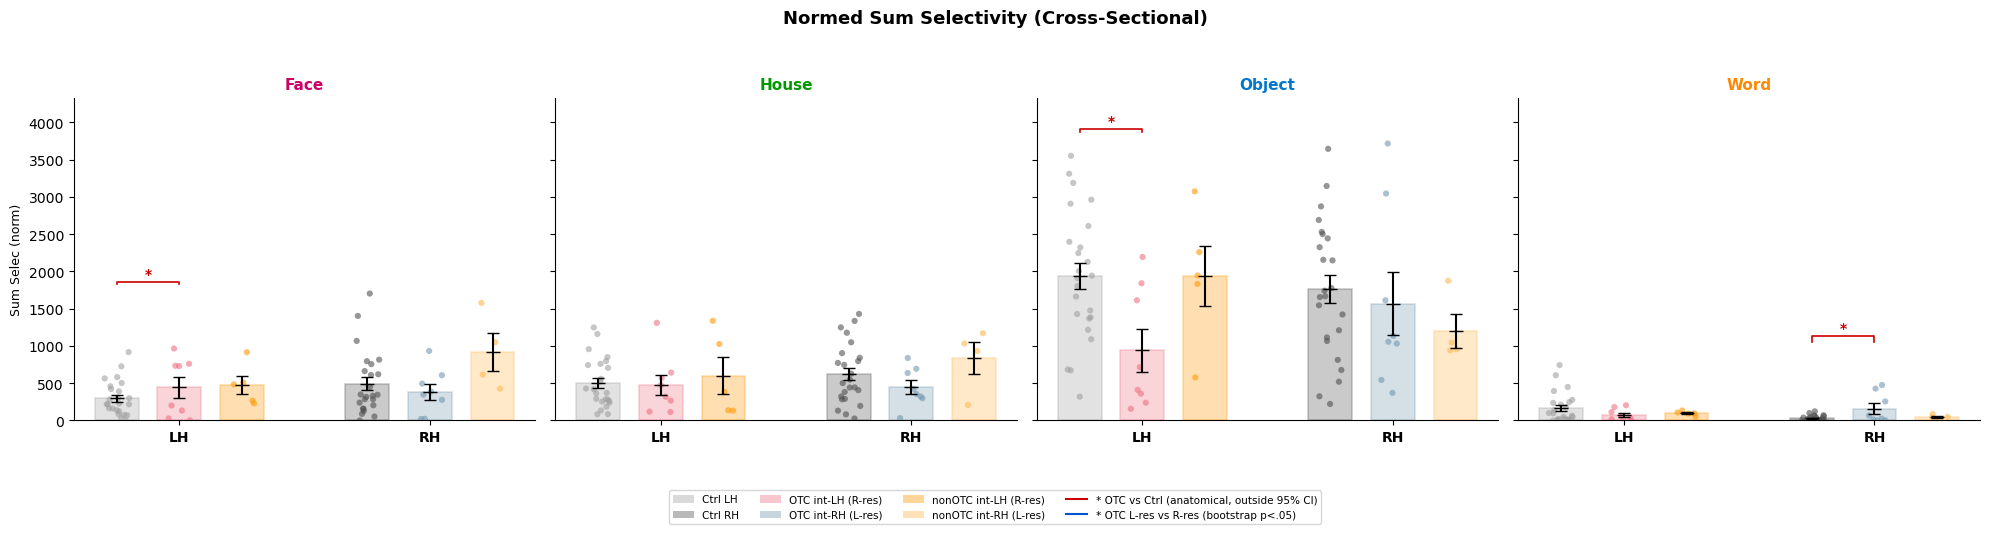

Saved: overview_sum_selec.png
  Significant comparisons:
  face: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*


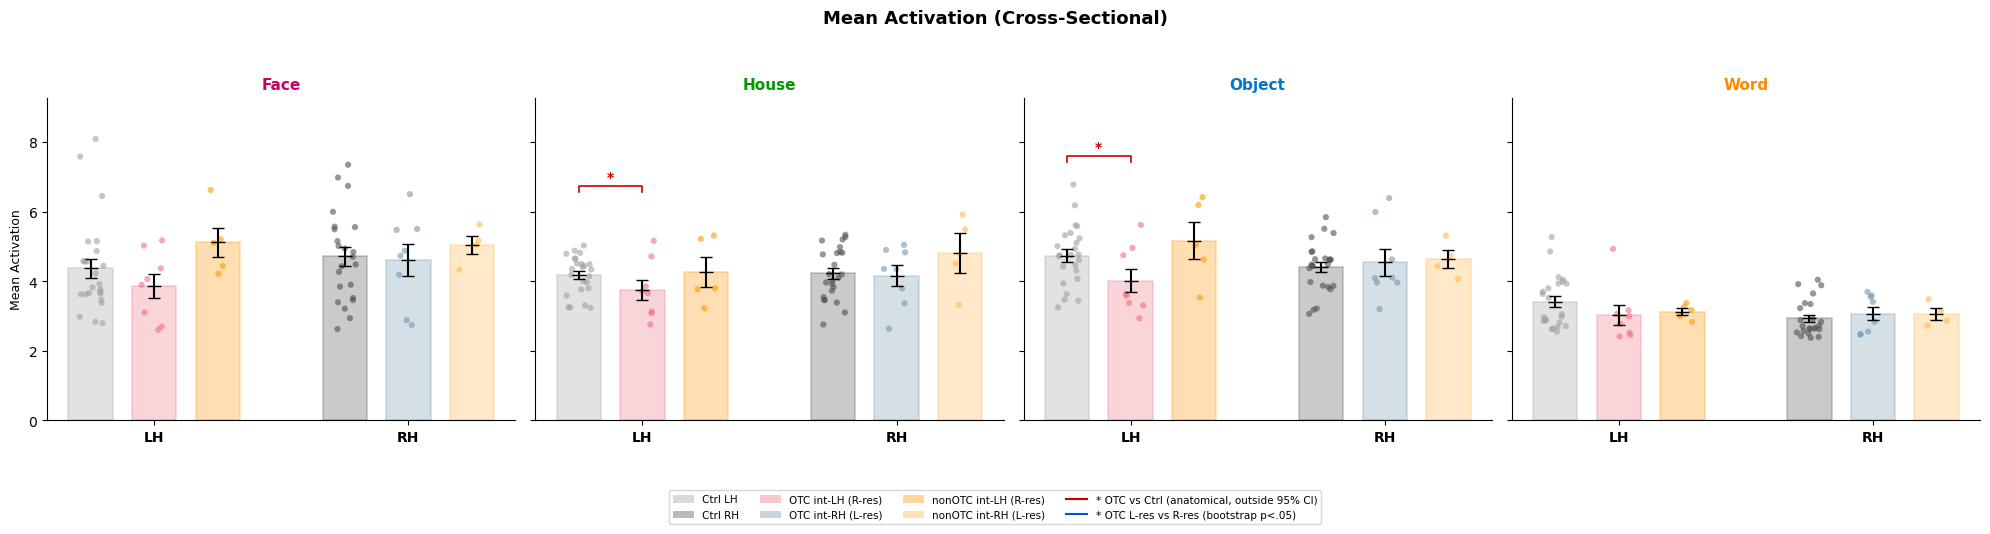

Saved: overview_mean_act.png
  Significant comparisons:
  house: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*


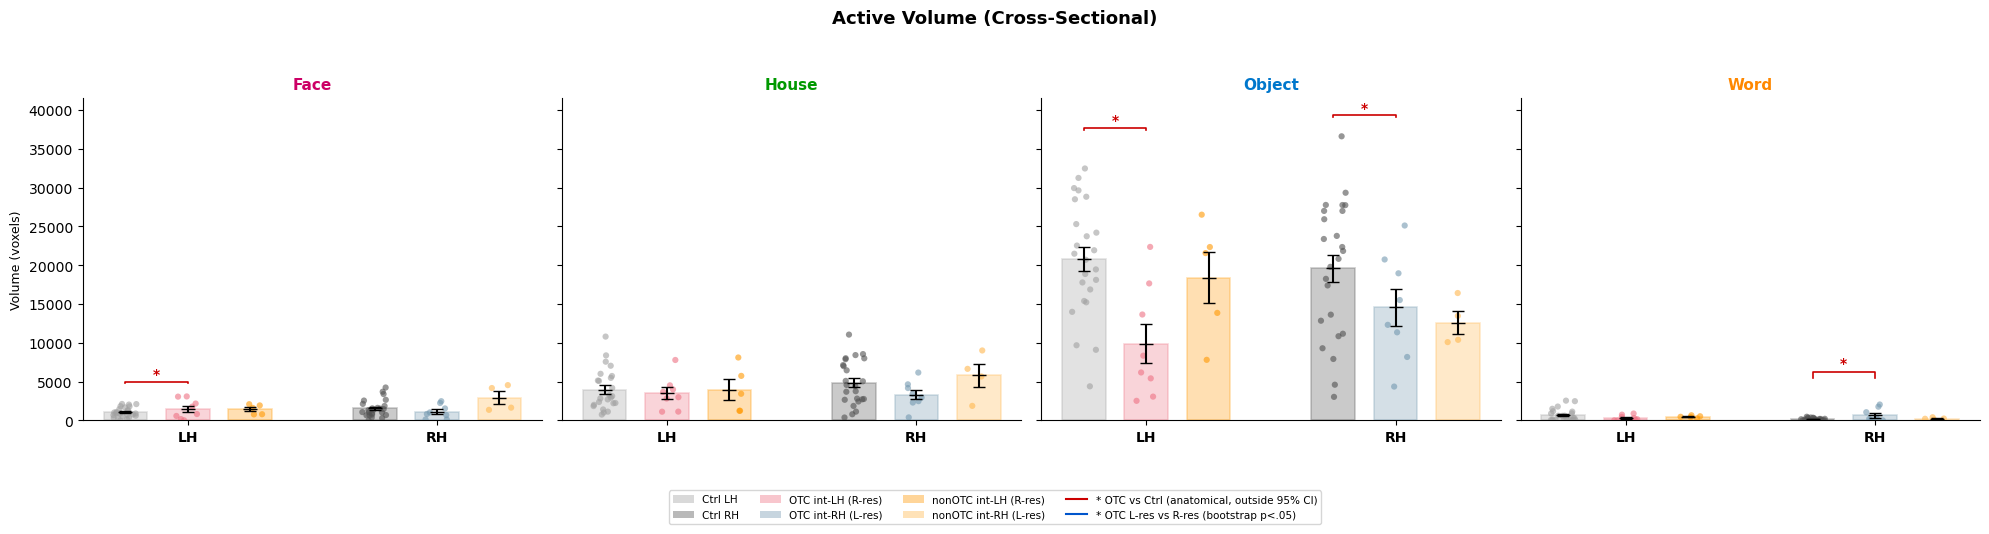

Saved: overview_volume.png
  Significant comparisons:
  face: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*


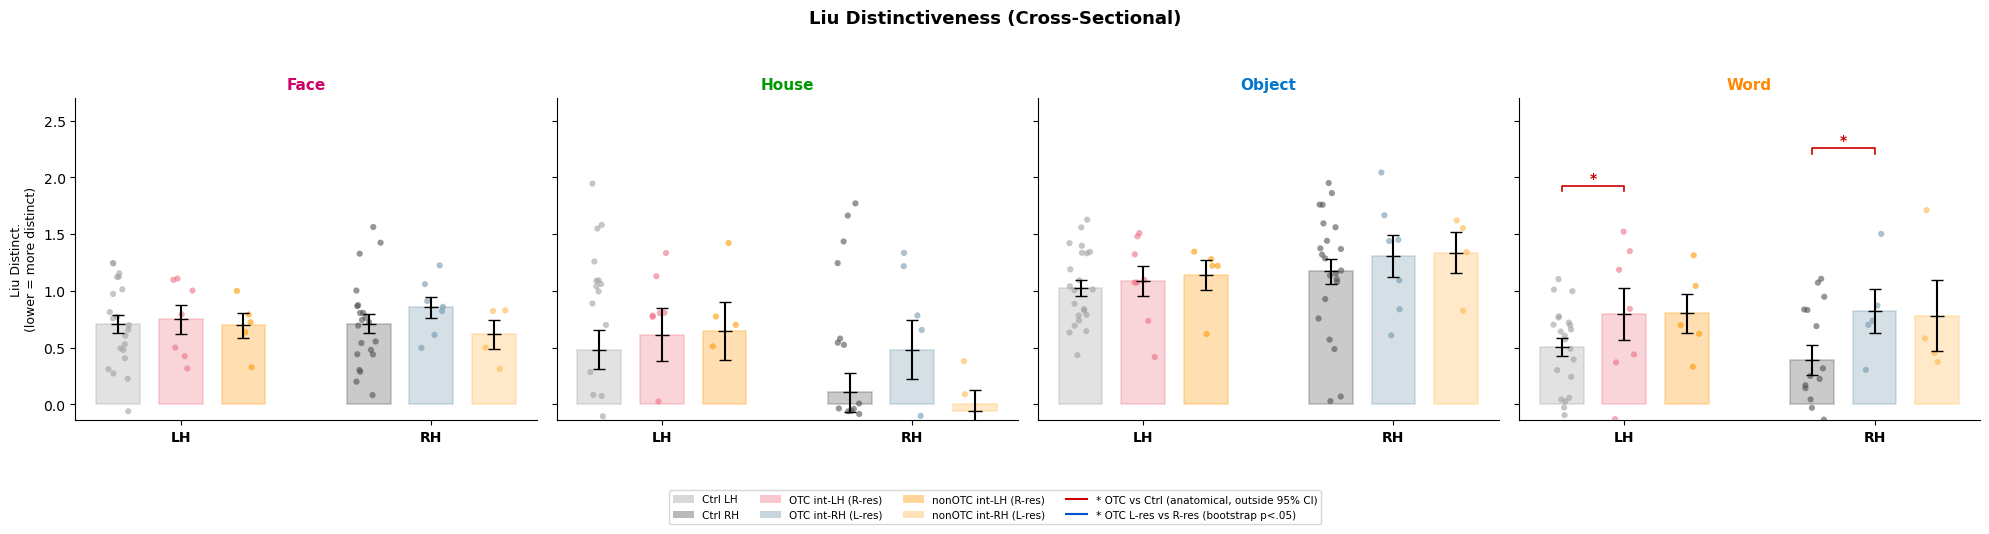

Saved: overview_liu_cs.png
  Significant comparisons:
  word: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*


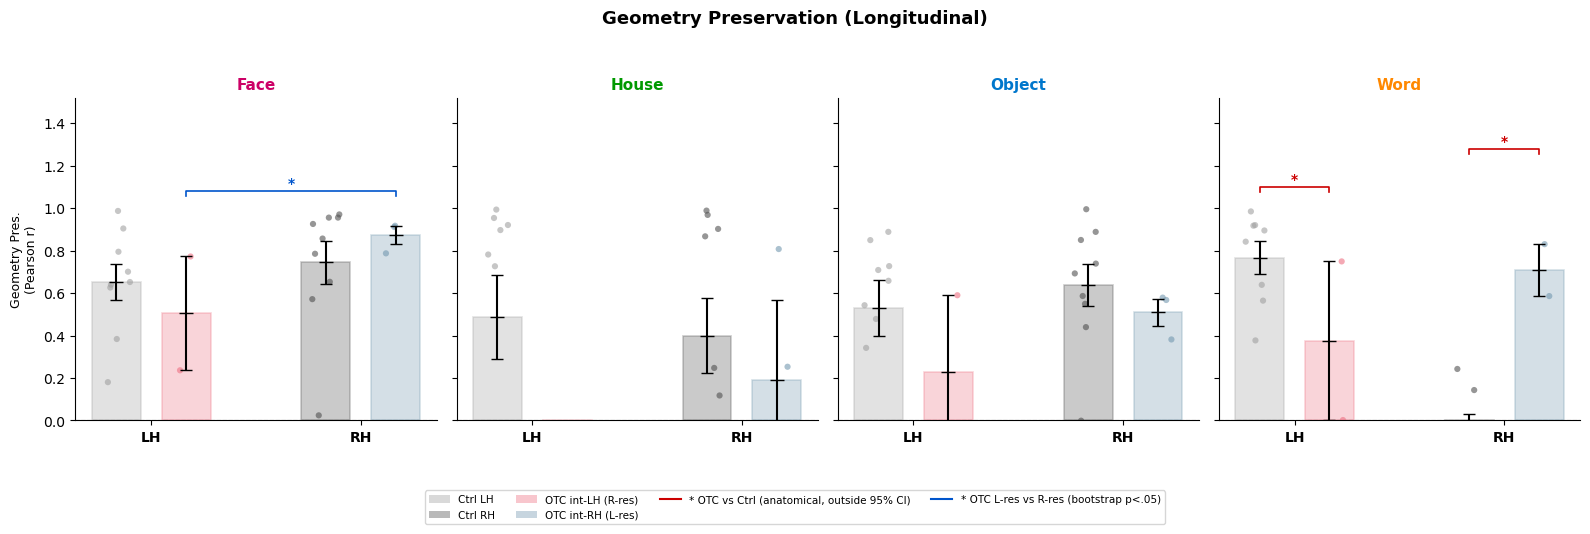

Saved: overview_geometry.png
  Significant comparisons:
  face: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)
  word: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*


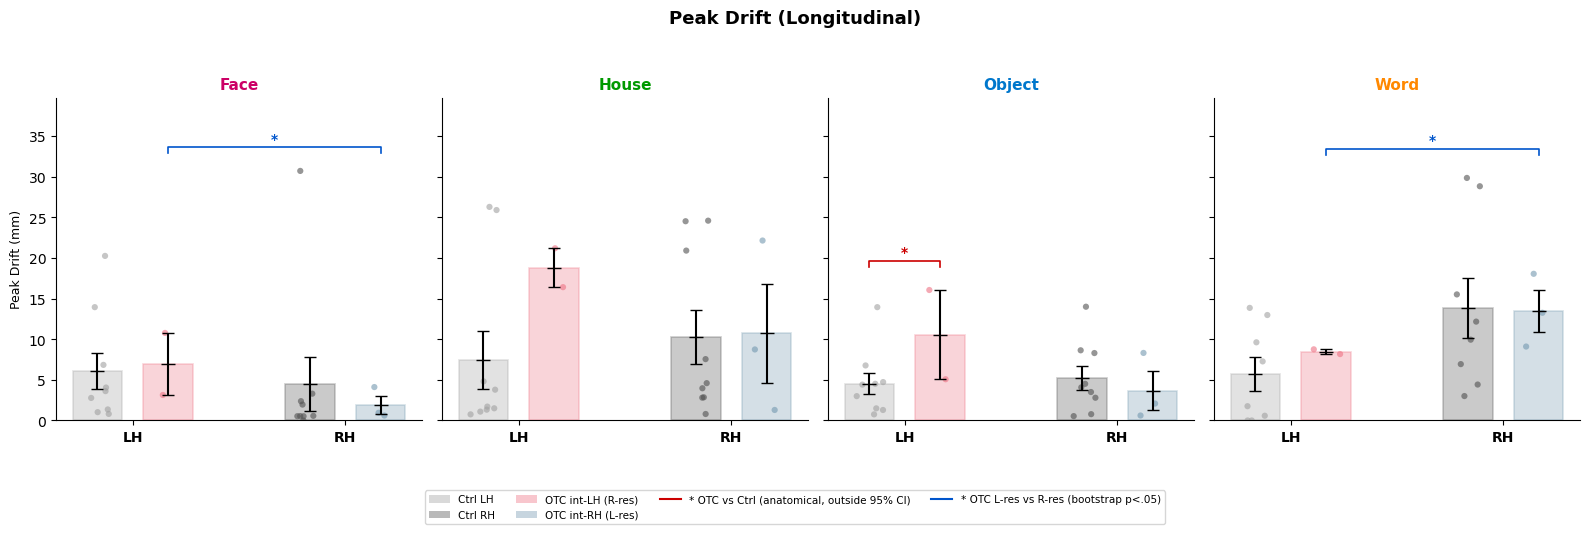

Saved: overview_peak_drift.png
  Significant comparisons:
  face: OTC L-res vs R-res — *SIGNIFICANT* (p=0.020)
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  word: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)


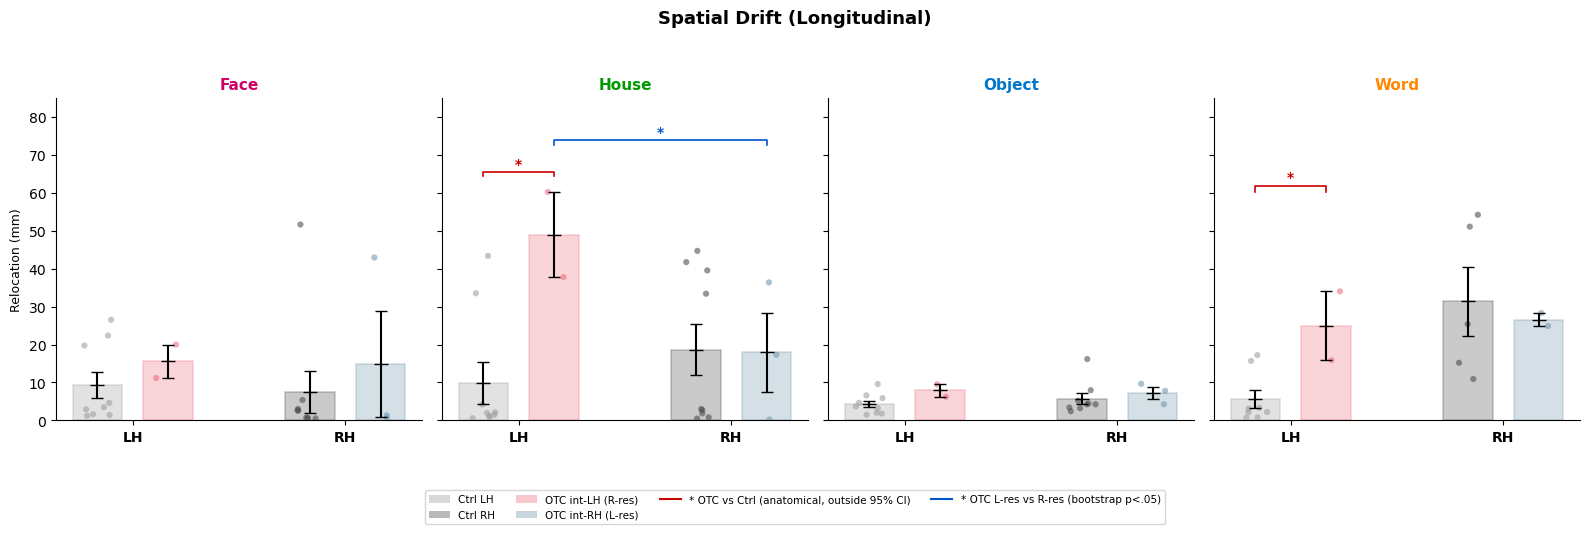

Saved: overview_spatial_drift.png
  Significant comparisons:
  house: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  house: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)
  word: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*


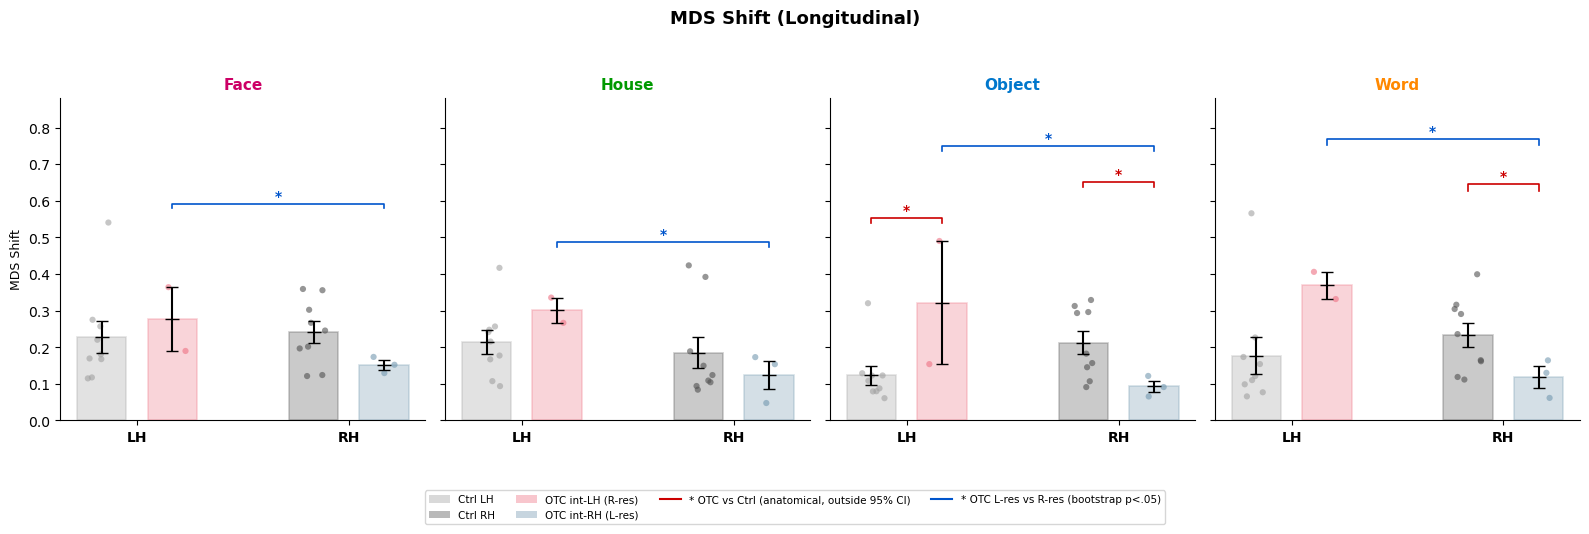

Saved: overview_mds_shift.png
  Significant comparisons:
  face: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)
  house: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*
  object: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*
  word: OTC L-res vs R-res — *SIGNIFICANT* (p=0.000)

SUMMARY: All significant comparisons across overview plots

sum_selec:
  face: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*

mean_act:
  house: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*

volume:
  face: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*
  object: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*
  word: OTC L-res (int RH) vs

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Standardized Measure Overview
# ═══════════════════════════════════════════════════════════════════════════════
# Bar + dot plot for every measure.
# Bars grouped by HEMISPHERE so anatomical comparisons are adjacent:
#   LH block: Ctrl LH | OTC intact-LH (R-resec) | [nonOTC intact-LH]
#   RH block: Ctrl RH | OTC intact-RH (L-resec) | [nonOTC intact-RH]
# Significance brackets:
#   Red:  OTC vs matched control (anatomical, outside 95% CI)
#   Blue: OTC L-res vs OTC R-res (bootstrap p<.05)
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci_quick(vals, n_draw=None, n_iter=10000, rng=RNG):
    v = np.asarray(vals, dtype=float); v = v[np.isfinite(v)]
    if len(v) < 3: return np.nan, np.nan
    if n_draw is None: n_draw = len(v)
    n_draw = min(n_draw, len(v))
    boot = np.array([rng.choice(v, size=n_draw, replace=False).mean() for _ in range(n_iter)])
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)

def bootstrap_p_quick(g1, g2, n_iter=10000, rng=RNG):
    g1 = np.asarray(g1, dtype=float); g1 = g1[np.isfinite(g1)]
    g2 = np.asarray(g2, dtype=float); g2 = g2[np.isfinite(g2)]
    if len(g1) < 2 or len(g2) < 2: return np.nan
    obs = np.mean(g1) - np.mean(g2)
    diffs = np.array([rng.choice(g1, len(g1), replace=True).mean() -
                       rng.choice(g2, len(g2), replace=True).mean()
                       for _ in range(n_iter)])
    centered = diffs - diffs.mean()
    return float(np.mean(np.abs(centered) >= np.abs(obs)))

def extract_measure(df, cat, vcol, schema='sel', include_nonotc=False, nonotc_df=None):
    c = df[df['category'] == cat] if 'category' in df.columns else df[df['measured_category'] == cat]
    out = {}
    if schema == 'sel':
        out['ctrl_lh'] = c[(c['group'] == 'control') & (c['hemi'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['group'] == 'control') & (c['hemi'] == 'right')][vcol].dropna().values
        otc_all = c[c['group'] == 'OTC']
        otc_intact = otc_all[otc_all['hemi'] == otc_all['intact_hemi']]
        out['otc_rh'] = otc_intact[otc_intact['intact_hemi'] == 'right'][vcol].dropna().values
        out['otc_lh'] = otc_intact[otc_intact['intact_hemi'] == 'left'][vcol].dropna().values
        if include_nonotc and nonotc_df is not None:
            nc = nonotc_df[nonotc_df['category'] == cat]
            nc_intact = nc[nc['hemi'] == nc['intact_hemi']]
            out['non_rh'] = nc_intact[nc_intact['intact_hemi'] == 'right'][vcol].dropna().values
            out['non_lh'] = nc_intact[nc_intact['intact_hemi'] == 'left'][vcol].dropna().values
    elif schema == 'geo':
        out['ctrl_lh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'right')][vcol].dropna().values
        otc_intact = c[(c['group'] == 'OTC') & (c['hemi_label'] == 'intact')]
        if 'surgery_side' in otc_intact.columns:
            out['otc_rh'] = otc_intact[otc_intact['surgery_side'] == 'left'][vcol].dropna().values
            out['otc_lh'] = otc_intact[otc_intact['surgery_side'] == 'right'][vcol].dropna().values
        else:
            out['otc_rh'] = np.array([]); out['otc_lh'] = np.array([])
        if include_nonotc and nonotc_df is not None:
            nc = nonotc_df[nonotc_df['category'] == cat] if 'category' in nonotc_df.columns else pd.DataFrame()
            if len(nc) > 0:
                nc_intact = nc[nc['hemi_label'] == 'intact'] if 'hemi_label' in nc.columns else nc
                if 'surgery_side' in nc_intact.columns:
                    out['non_rh'] = nc_intact[nc_intact['surgery_side'] == 'left'][vcol].dropna().values
                    out['non_lh'] = nc_intact[nc_intact['surgery_side'] == 'right'][vcol].dropna().values
                else:
                    out['non_rh'] = np.array([]); out['non_lh'] = np.array([])
    elif schema == 'drift':
        out['ctrl_lh'] = c[(c['group'] == 'control') & (c['hemi'] == 'left')][vcol].dropna().values
        out['ctrl_rh'] = c[(c['group'] == 'control') & (c['hemi'] == 'right')][vcol].dropna().values
        otc_c = c[c['group'] == 'OTC']
        out['otc_rh'] = otc_c[(otc_c['intact_hemi'] == 'right') & (otc_c['hemi'] == 'right')][vcol].dropna().values
        out['otc_lh'] = otc_c[(otc_c['intact_hemi'] == 'left') & (otc_c['hemi'] == 'left')][vcol].dropna().values
    return out

def draw_bracket(ax, x1, x2, y, text, color='black', lw=1.2, fontsize=10):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color=color, linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h * 1.2, text, ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold', color=color)

def plot_measure_row(data_fn, title, ylabel, figname, show_zero=False,
                     show_nonotc=False):
    # ── Positions: grouped by hemisphere ──────────────────────────────
    # LH block                          gap    RH block
    # Ctrl_LH  OTC_intLH  [non_intLH]   |   Ctrl_RH  OTC_intRH  [non_intRH]
    if show_nonotc:
        P_CLH = 0; P_OLH = 1; P_NLH = 2; P_CRH = 4; P_ORH = 5; P_NRH = 6
        figw = 20
    else:
        P_CLH = 0; P_OLH = 1; P_CRH = 3; P_ORH = 4
        figw = 16

    fig, axes = plt.subplots(1, 4, figsize=(figw, 5), sharey=True)

    # Build group list dynamically
    groups = [
        ('Ctrl LH',          'ctrl_lh', CTRL_L,   P_CLH),
        ('OTC int-LH\n(R-res)', 'otc_lh',  OTC_R,    P_OLH),
    ]
    if show_nonotc:
        groups.append(('non int-LH\n(R-res)', 'non_lh', NONOT, P_NLH))
    groups += [
        ('Ctrl RH',          'ctrl_rh', CTRL_R,   P_CRH),
        ('OTC int-RH\n(L-res)', 'otc_rh',  OTC_L,    P_ORH),
    ]
    if show_nonotc:
        groups.append(('non int-RH\n(L-res)', 'non_rh', '#FFB74D', P_NRH))

    # Collect significance results for text summary
    sig_results = []

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        d = data_fn(cat)
        all_vals_max = 0

        for label, key, color, pos in groups:
            vals = d.get(key, np.array([]))
            if len(vals) == 0:
                continue
            all_vals_max = max(all_vals_max, np.max(vals), abs(np.mean(vals)))

            ax.bar(pos, np.mean(vals), width=0.7, color=color, alpha=0.3,
                   edgecolor=color, linewidth=1.2)
            jit = RNG.uniform(-0.2, 0.2, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.6, s=20, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0,
                        color='black', marker='_', markersize=10,
                        capsize=4, linewidth=1.5, zorder=5)

        if show_zero:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

        # ── Significance brackets ─────────────────────────────────────
        ax.autoscale_view()
        ymin, ymax = ax.get_ylim()
        bracket_step = (ymax - ymin) * 0.07
        next_y = all_vals_max + bracket_step

        # 1a) LH anatomical: Ctrl LH vs OTC intact-LH (adjacent)
        otc_lh_v = d.get('otc_lh', np.array([]))
        ctrl_lh_v = d.get('ctrl_lh', np.array([]))
        if len(otc_lh_v) > 0 and len(ctrl_lh_v) >= 3:
            ci_lo, ci_hi = bootstrap_ci_quick(ctrl_lh_v, n_draw=max(1, len(otc_lh_v)))
            m = np.mean(otc_lh_v)
            if np.isfinite(ci_lo) and (m < ci_lo or m > ci_hi):
                draw_bracket(ax, P_CLH, P_OLH, next_y, '*', color='#cc0000')
                next_y += bracket_step * 2
                sig_results.append(f'  {cat}: OTC R-res (int LH) vs Ctrl LH — *SIGNIFICANT*')

        # 1b) RH anatomical: Ctrl RH vs OTC intact-RH (adjacent)
        otc_rh_v = d.get('otc_rh', np.array([]))
        ctrl_rh_v = d.get('ctrl_rh', np.array([]))
        if len(otc_rh_v) > 0 and len(ctrl_rh_v) >= 3:
            ci_lo, ci_hi = bootstrap_ci_quick(ctrl_rh_v, n_draw=max(1, len(otc_rh_v)))
            m = np.mean(otc_rh_v)
            if np.isfinite(ci_lo) and (m < ci_lo or m > ci_hi):
                draw_bracket(ax, P_CRH, P_ORH, next_y, '*', color='#cc0000')
                next_y += bracket_step * 2
                sig_results.append(f'  {cat}: OTC L-res (int RH) vs Ctrl RH — *SIGNIFICANT*')

        # 2) OTC L-res vs R-res (cross-hemisphere bracket)
        if len(otc_rh_v) >= 2 and len(otc_lh_v) >= 2:
            p_within = bootstrap_p_quick(otc_rh_v, otc_lh_v)
            if np.isfinite(p_within) and p_within < 0.05:
                draw_bracket(ax, P_OLH, P_ORH, next_y, '*', color='#0055cc')
                next_y += bracket_step * 2
                sig_results.append(f'  {cat}: OTC L-res vs R-res — *SIGNIFICANT* (p={p_within:.3f})')

        if next_y > ymax:
            ax.set_ylim(ymin, next_y + bracket_step)

        # X-axis labels
        if show_nonotc:
            ax.set_xticks([(P_CLH + P_NLH) / 2, (P_CRH + P_NRH) / 2])
        else:
            ax.set_xticks([(P_CLH + P_OLH) / 2, (P_CRH + P_ORH) / 2])
        ax.set_xticklabels(['LH', 'RH'], fontsize=10, fontweight='bold')
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)

    # ── Legend ────────────────────────────────────────────────────────
    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.4, label='Ctrl LH'),
        Patch(facecolor=CTRL_R, alpha=0.4, label='Ctrl RH'),
        Patch(facecolor=OTC_R, alpha=0.4, label='OTC int-LH (R-res)'),
        Patch(facecolor=OTC_L, alpha=0.4, label='OTC int-RH (L-res)'),
    ]
    if show_nonotc:
        legend_elements += [
            Patch(facecolor=NONOT, alpha=0.4, label='nonOTC int-LH (R-res)'),
            Patch(facecolor='#FFB74D', alpha=0.4, label='nonOTC int-RH (L-res)'),
        ]
    legend_elements += [
        Line2D([0], [0], color='#cc0000', linewidth=1.5,
               label='* OTC vs Ctrl (anatomical, outside 95% CI)'),
        Line2D([0], [0], color='#0055cc', linewidth=1.5,
               label='* OTC L-res vs R-res (bootstrap p<.05)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=7.5, frameon=True, bbox_to_anchor=(0.5, -0.06))

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.savefig(str(FIG_DIR / figname), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figname}')

    # Print text summary of significant results
    if sig_results:
        print('  Significant comparisons:')
        for s in sig_results:
            print(s)
    else:
        print('  No significant comparisons.')
    return sig_results


# ═══════════════════════════════════════════════════════════════════════════
# Prepare nonOTC subsets
# ═══════════════════════════════════════════════════════════════════════════
nonotc_sel = df_sel_cs[df_sel_cs['group'] == 'nonOTC'].copy()
nonotc_sel['surgery_side'] = nonotc_sel['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')
nonotc_liu = df_liu_cs[df_liu_cs['group'] == 'nonOTC'].copy()

# ═══════════════════════════════════════════════════════════════════════════
# CROSS-SECTIONAL MEASURES (with nonOTC)
# ═══════════════════════════════════════════════════════════════════════════
all_sig = {}

all_sig['sum_selec'] = plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'sum_selec_norm', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Normed Sum Selectivity (Cross-Sectional)', 'Sum Selec (norm)',
    'overview_sum_selec.png', show_nonotc=True)

all_sig['mean_act'] = plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'mean_act', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Mean Activation (Cross-Sectional)', 'Mean Activation',
    'overview_mean_act.png', show_nonotc=True)

all_sig['volume'] = plot_measure_row(
    lambda cat: extract_measure(df_sel_cs, cat, 'volume', 'sel',
                                include_nonotc=True, nonotc_df=nonotc_sel),
    'Active Volume (Cross-Sectional)', 'Volume (voxels)',
    'overview_volume.png', show_nonotc=True)

all_sig['liu_cs'] = plot_measure_row(
    lambda cat: extract_measure(df_liu_cs, cat, 'liu_distinctiveness', 'geo',
                                include_nonotc=True, nonotc_df=nonotc_liu),
    'Liu Distinctiveness (Cross-Sectional)', 'Liu Distinct.\n(lower = more distinct)',
    'overview_liu_cs.png', show_nonotc=True)

# ═══════════════════════════════════════════════════════════════════════════
# LONGITUDINAL MEASURES (OTC only)
# ═══════════════════════════════════════════════════════════════════════════

all_sig['geometry'] = plot_measure_row(
    lambda cat: extract_measure(df_geo, cat, 'geometry_preservation', 'geo'),
    'Geometry Preservation (Longitudinal)', 'Geometry Pres.\n(Pearson r)',
    'overview_geometry.png', show_zero=True)

# Peak Drift
grp_cols = ['sub', 'category', 'hemi']
idx_first = df_peak.groupby(grp_cols)['ses_num'].idxmin()
idx_last  = df_peak.groupby(grp_cols)['ses_num'].idxmax()
pk_t1 = df_peak.loc[idx_first].set_index(grp_cols)
pk_tl = df_peak.loc[idx_last].set_index(grp_cols)
multi_idx = pk_t1.index[pk_t1['ses_num'] != pk_tl.loc[pk_t1.index, 'ses_num']]
pk_t1, pk_tl = pk_t1.loc[multi_idx], pk_tl.loc[multi_idx]
drift = pd.DataFrame(index=multi_idx)
drift['peak_drift_mm'] = np.sqrt(
    (pk_tl['peak_x_mni'] - pk_t1['peak_x_mni'])**2 +
    (pk_tl['peak_y_mni'] - pk_t1['peak_y_mni'])**2 +
    (pk_tl['peak_z_mni'] - pk_t1['peak_z_mni'])**2)
drift['group'] = pk_t1['group']
drift['intact_hemi'] = pk_t1['intact_hemi']
drift = drift.reset_index()

all_sig['peak_drift'] = plot_measure_row(
    lambda cat: extract_measure(drift, cat, 'peak_drift_mm', 'drift'),
    'Peak Drift (Longitudinal)', 'Peak Drift (mm)', 'overview_peak_drift.png')

if df_spatial is not None:
    all_sig['spatial'] = plot_measure_row(
        lambda cat: extract_measure(df_spatial, cat, 'relocation_mm', 'geo'),
        'Spatial Drift (Longitudinal)', 'Relocation (mm)', 'overview_spatial_drift.png')

if df_mds is not None:
    otc_mds = df_mds[(df_mds['group'] == 'OTC') & (df_mds['hemi_label'] == 'intact')]
    ctrl_mds = df_mds[df_mds['status'] == 'control']
    gcols = ['subject', 'measured_category', 'hemi_label', 'group', 'status'] + (
        ['surgery_side'] if 'surgery_side' in df_mds.columns else [])
    mds_avg = pd.concat([
        otc_mds.groupby(gcols)['mds_shift'].mean().reset_index(),
        ctrl_mds.groupby([c for c in gcols if c != 'surgery_side'] if 'surgery_side' not in ctrl_mds.columns else gcols)['mds_shift'].mean().reset_index()
    ])
    def mds_extract(cat):
        c = mds_avg[mds_avg['measured_category'] == cat]
        out = {}
        out['ctrl_lh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'left')]['mds_shift'].dropna().values
        out['ctrl_rh'] = c[(c['status'] == 'control') & (c['hemi_label'] == 'right')]['mds_shift'].dropna().values
        otc_c = c[c['group'] == 'OTC']
        if 'surgery_side' in otc_c.columns:
            out['otc_rh'] = otc_c[otc_c['surgery_side'] == 'left']['mds_shift'].dropna().values
            out['otc_lh'] = otc_c[otc_c['surgery_side'] == 'right']['mds_shift'].dropna().values
        else:
            out['otc_rh'] = np.array([]); out['otc_lh'] = np.array([])
        return out
    all_sig['mds'] = plot_measure_row(mds_extract, 'MDS Shift (Longitudinal)', 'MDS Shift',
                                       'overview_mds_shift.png')

# ═══════════════════════════════════════════════════════════════════════════
# SUMMARY: All significant comparisons
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 70)
print('SUMMARY: All significant comparisons across overview plots')
print('=' * 70)
for measure, sigs in all_sig.items():
    if sigs:
        print(f'\n{measure}:')
        for s in sigs:
            print(s)
    else:
        print(f'\n{measure}: no significant comparisons')